# E-commerce Marketing Campaign — Exploratory Data Analysis (EDA)

This notebook performs an end-to-end, **advanced EDA** on the `train.csv` dataset.


Import Data > Clean Data > Feature Engineering > EDA


## 1. Data Import & Initial Inspection

## Setup and Library Imports

In [1]:
import itertools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from fuzzywuzzy import process
from sklearn.preprocessing import LabelEncoder
sns.set()

## Load the Dataset

In [2]:
df = pd.read_csv("train.csv")

## Initial Data Inspection - Shape and Columns

In [3]:
print(df.shape)
print(df.columns.tolist())
df.head()

(18000, 17)
['id', 'date', 'region', 'channel', 'product_category', 'customer_segment', 'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions', 'click_through_rate', 'competition_index', 'seasonality_index', 'campaign_duration_days', 'customer_lifetime_value', 'sales_revenue']


,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


## Data Overview - Info and Missing Values

In [4]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

## Initial Categorical/Numerical Variable Identification

In [5]:
cats = list(df.select_dtypes(include=['object']).columns)
nums = list(df.select_dtypes(exclude=['object']).columns)
print(f'Categorical variables: {cats}')
print(f'Numerical variables: {nums}')
print("\nUnique values per column:")
print(df.nunique(axis=0))

Categorical variables: ['date', 'region', 'channel', 'product_category', 'customer_segment']
Numerical variables: ['id', 'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions', 'click_through_rate', 'competition_index', 'seasonality_index', 'campaign_duration_days', 'customer_lifetime_value', 'sales_revenue']

Unique values per column:
id                         18000
date                       11926
region                        10
channel                       11
product_category               6
customer_segment               3
ad_spend                    1207
price                        474
discount_rate               5125
market_reach                 527
impressions                10887
click_through_rate          2103
competition_index            926
seasonality_index             12
campaign_duration_days         7
customer_lifetime_value    16932
sales_revenue              18000
dtype: int64


## Identify Low-Unique Value Columns as Potential Categories

In [6]:
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count < 20:
        print(f"{col} is likely Categorical (Unique: {unique_count})")

region is likely Categorical (Unique: 10)
channel is likely Categorical (Unique: 11)
product_category is likely Categorical (Unique: 6)
customer_segment is likely Categorical (Unique: 3)
seasonality_index is likely Categorical (Unique: 12)
campaign_duration_days is likely Categorical (Unique: 7)


## Update Categorical/Numerical Lists (Based on Logic)

In [7]:
cats = list(df.select_dtypes(include=['object']).columns)
nums = list(df.select_dtypes(include=['object']).columns)

threshold = 15

for col in nums[:]:
    if df[col].nunique() <= threshold:
        cats.append(col)
        nums.remove(col)

if 'id' in nums:
    nums.remove('id')

print(f'Final Categorical variables: {cats}')
print(f'Final Numerical variables: {nums}')

Final Categorical variables: ['date', 'region', 'channel', 'product_category', 'customer_segment', 'region', 'channel', 'product_category', 'customer_segment']
Final Numerical variables: ['date']


## 2. Data Cleaning

## Detailed Missing Value Analysis

In [8]:
print(df[df.isnull().any(axis=1)])
missing_pct = (df.isnull().sum() / len(df) * 100)
print(missing_pct)

          id                 date region       channel product_category  \
8          9  2010-04-28 10:02:00  North        Search          Storage   
9         10  2009-12-20 15:38:00  North     Affiliate          Kitchen   
10        11  2010-04-20 17:25:00  North  Social Media          General   
15        16  2010-07-05 12:49:00  North         Email       Stationery   
28        29  2010-12-09 13:03:00  North     Affiliate          Storage   
...      ...                  ...    ...           ...              ...   
17973  17974  2010-07-08 13:49:00  NORTH            TV          Storage   
17980  17981  2011-03-15 13:13:00   East    Influencer          Kitchen   
17982  17983  2011-07-07 13:35:00  North    Influencer          General   
17990  17991  2011-11-20 12:11:00  North        Search          General   
17997  17998  2010-09-28 10:24:00  North         Email          General   

      customer_segment  ad_spend  price  discount_rate  market_reach  \
8              Premium     

## Visualizing Missing Values (Heatmap)

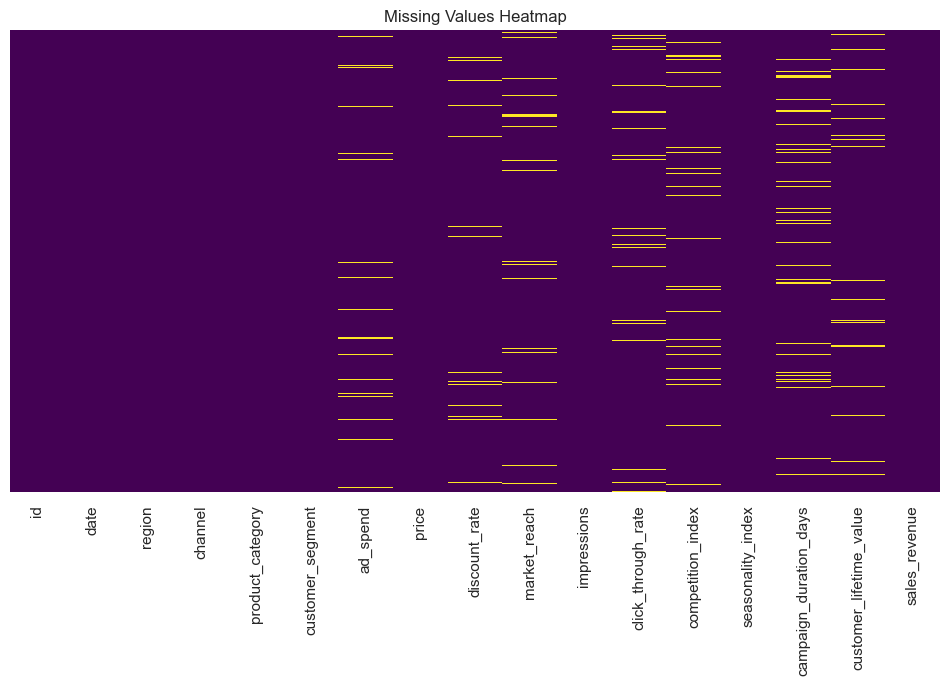

In [9]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

## Visualizing Outliers in Columns with Missing Data

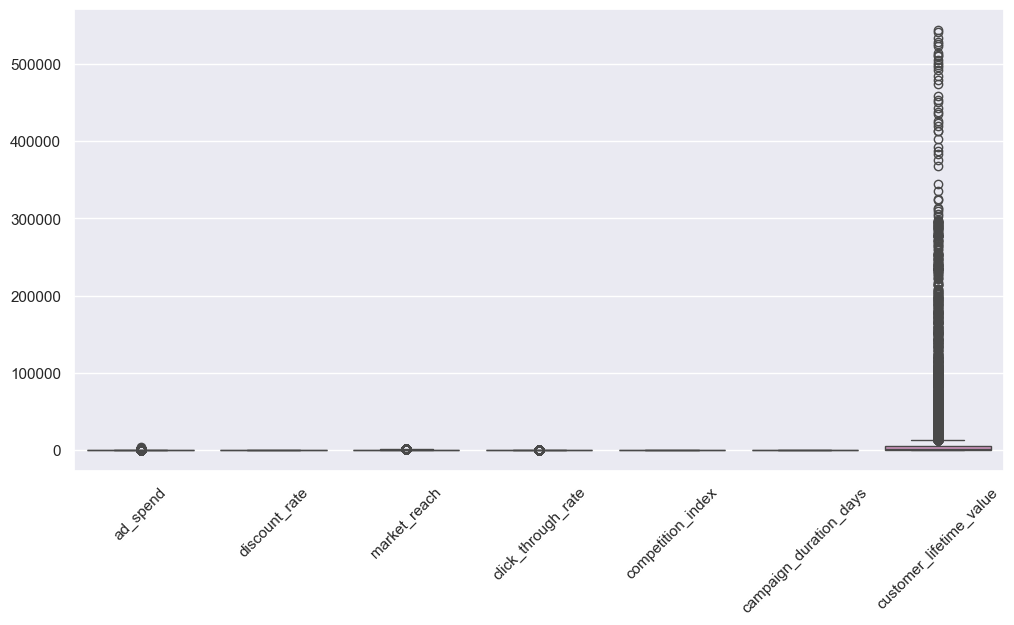

In [10]:
cols_with_nan = df.columns[df.isnull().any()].tolist()

if cols_with_nan:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[cols_with_nan])
    plt.xticks(rotation=45)
    plt.show()

## Outlier Analysis with Individual Boxplots

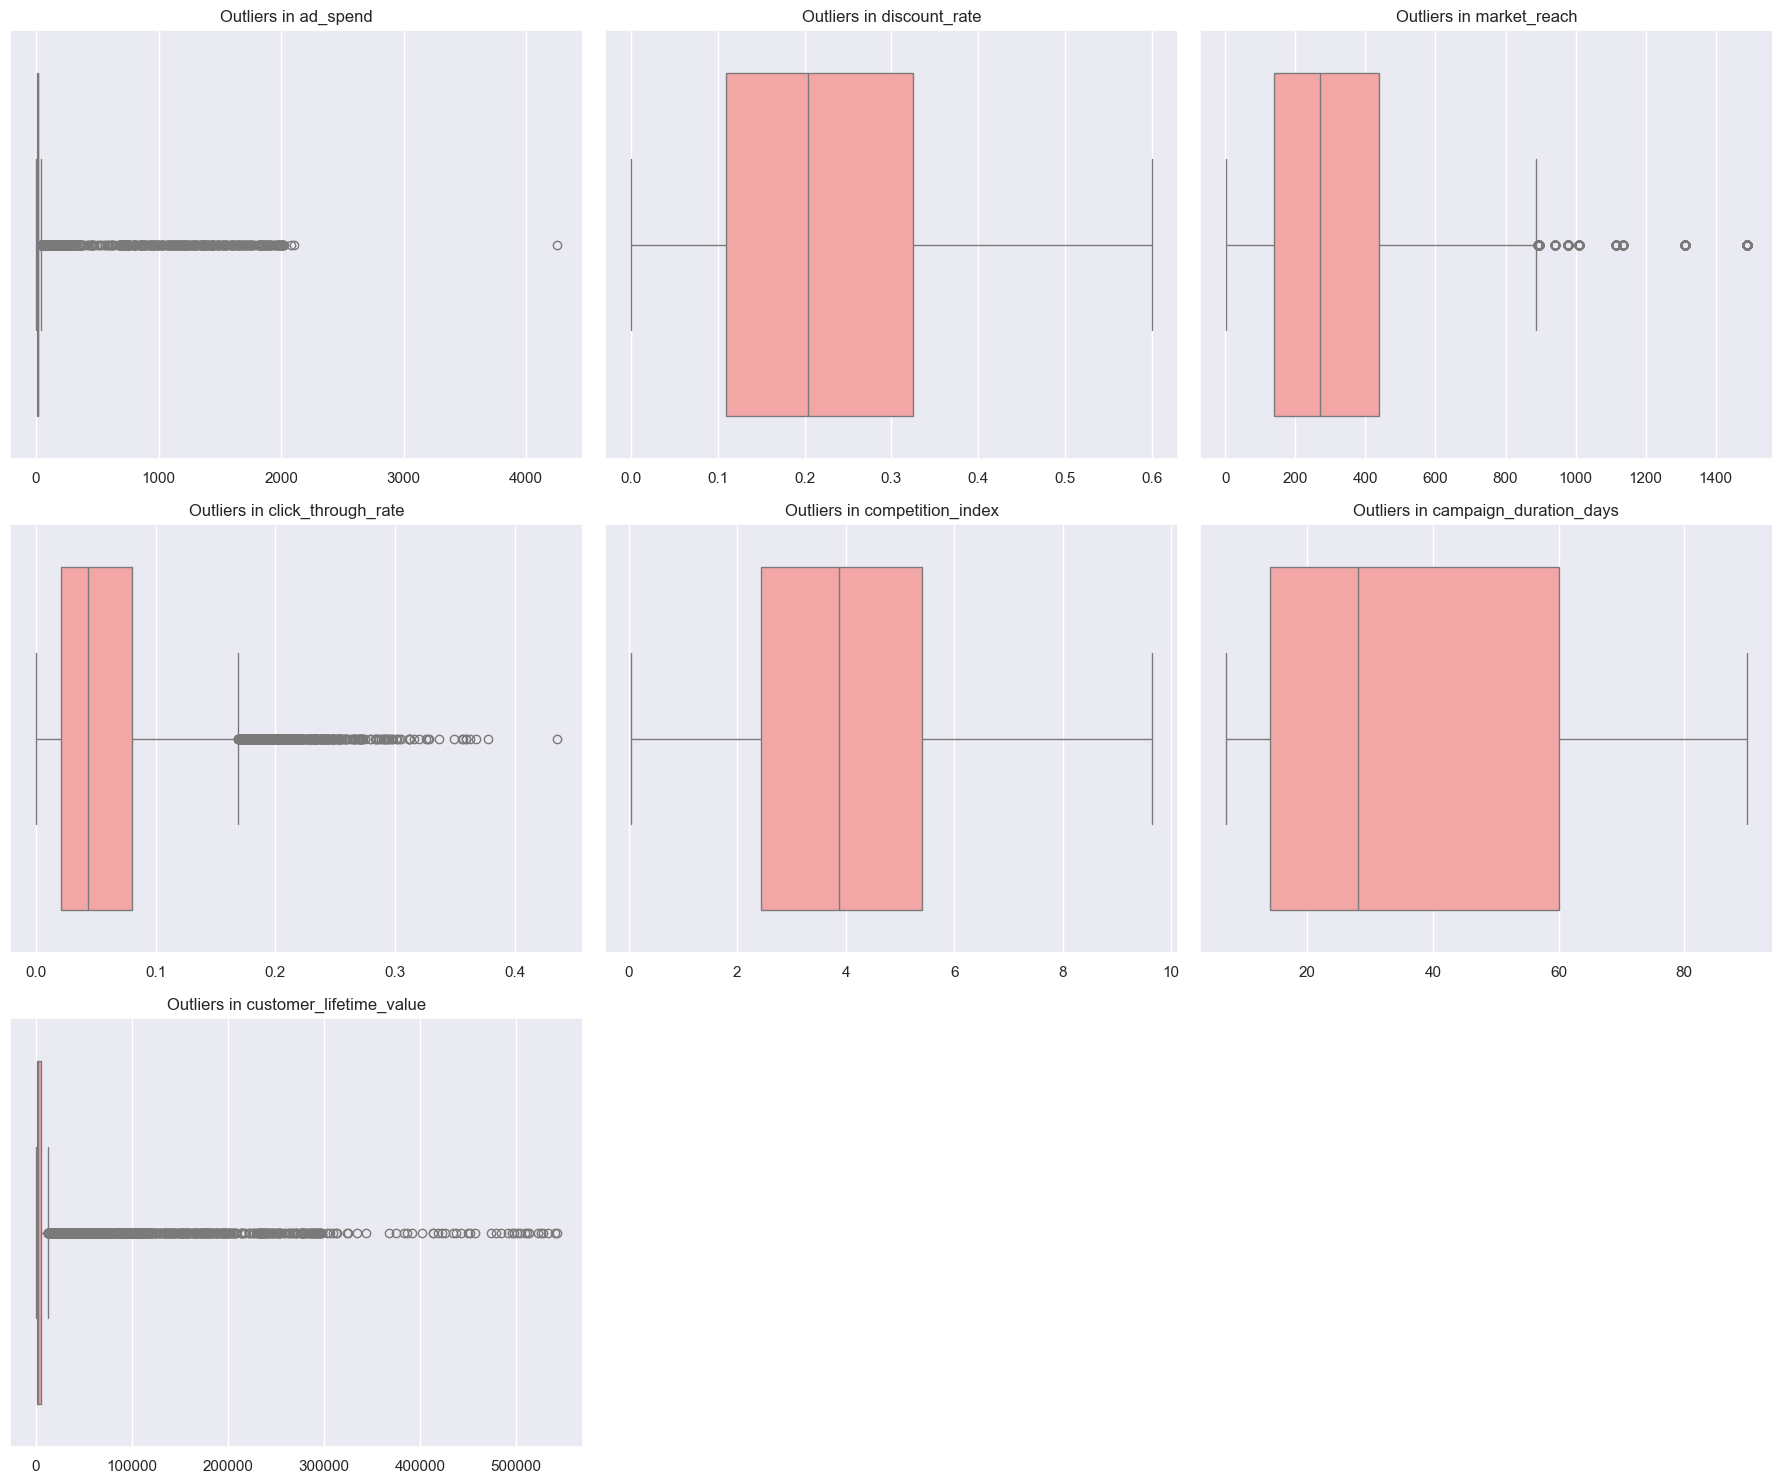

In [11]:
cols_with_nan = df.columns[df.isnull().any()].tolist()

if cols_with_nan:
    ncols = 3
    nrows = (len(cols_with_nan) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols_with_nan):
        sns.boxplot(x=df[col], ax=axes[i], color="#ff9999")
        axes[i].set_title(f"Outliers in {col}")
        axes[i].set_xlabel("")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## Data Cleaning - Handling Missing Values

In [12]:
drop_threshold = 50.0

for col in df.columns:
    
    pct = missing_pct[col]
    
    if pct > 0:
        
        if pct > drop_threshold:
            print(f"Dropping '{col}' because {pct:.2f}% data is missing.")
            df.drop(columns=[col], inplace=True)
        
        else:
            
            if df[col].dtype in ['int64', 'float64']:
                
                if abs(df[col].skew()) > 1:
                    df[col] = df[col].fillna(df[col].median())
                    print(f"Filled '{col}' with Median (Outliers detected).")
                
                else:
                    df[col] = df[col].fillna(df[col].mean())
                    print(f"Filled '{col}' with Mean (No outliers).")
            
            else:
                df[col] = df[col].fillna(df[col].mode()[0])
                print(f"Filled '{col}' with Mode (Categorical data).")

print("\n ==== Data Cleaning Complete! ====")
df.shape

Filled 'ad_spend' with Median (Outliers detected).
Filled 'discount_rate' with Mean (No outliers).
Filled 'market_reach' with Median (Outliers detected).
Filled 'click_through_rate' with Median (Outliers detected).
Filled 'competition_index' with Mean (No outliers).
Filled 'campaign_duration_days' with Mean (No outliers).
Filled 'customer_lifetime_value' with Median (Outliers detected).

 ==== Data Cleaning Complete! ====


(18000, 17)

## Data Cleaning - Removing Duplicates

In [13]:
print(f"Total duplicate rows: {df.duplicated().sum()}")
df = df[~df.duplicated()]
print(f"Shape after removing duplicates: {df.shape}")

Total duplicate rows: 0
Shape after removing duplicates: (18000, 17)


## Reorganize Columns (Categorical First)

In [14]:
cats = list(df.select_dtypes(include=['object']).columns)
nums = list(df.select_dtypes(exclude=['object']).columns)

df = pd.concat([df[cats], df[nums]], axis=1)
print("Columns have been grouped: Categorical first, then Numerical.")
df.head()

Columns have been grouped: Categorical first, then Numerical.


,date,region,channel,product_category,customer_segment,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,2011-12-05 11:31:00,Nort,Search,General,Standard,1,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2011-04-27 14:01:00,North,Social Media,General,Premium,2,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,2010-11-09 15:20:00,North,Affiliate,General,Budget,3,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,4,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,2011-10-14 09:28:00,North,Search,Lighting,Premium,5,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


## Inspect Unique Values in Categorical Columns

In [15]:
for col in cats:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in date: ['2011-12-05 11:31:00' '2011-04-27 14:01:00' '2010-11-09 15:20:00' ...
 '2011-01-13 13:21:00' '2010-11-09 14:11:00' '2011-11-20 12:11:00']
Unique values in region: ['Nort' 'North' 'north' 'NORTH' 'Central' 'Norht' 'north ' 'East' 'West'
 'South']
Unique values in channel: ['Search' 'Social Media' 'Affiliate' 'Email' 'TV' 'Influencer'
 'Social_Media' 'Socail Media' 'social Media' 'SocialMedia' 'social media']
Unique values in product_category: ['General' 'Storage' 'Lighting' 'Stationery' 'Kitchen' 'Seasonal']
Unique values in customer_segment: ['Standard' 'Premium' 'Budget']


## Final Data Types and Text Column Check

In [16]:
df.info()
text_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Text Columns: {text_cols}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     18000 non-null  object 
 1   region                   18000 non-null  object 
 2   channel                  18000 non-null  object 
 3   product_category         18000 non-null  object 
 4   customer_segment         18000 non-null  object 
 5   id                       18000 non-null  int64  
 6   ad_spend                 18000 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            18000 non-null  float64
 9   market_reach             18000 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       18000 non-null  float64
 12  competition_index        18000 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

## Count Unique Values in Text Columns

In [17]:
for col in text_cols:
    print(f"Column: {col} | Unique Values Count: {df[col].nunique()}")
    print(f"Actual Values: {df[col].unique()}\n")

Column: date | Unique Values Count: 11926
Actual Values: ['2011-12-05 11:31:00' '2011-04-27 14:01:00' '2010-11-09 15:20:00' ...
 '2011-01-13 13:21:00' '2010-11-09 14:11:00' '2011-11-20 12:11:00']

Column: region | Unique Values Count: 10
Actual Values: ['Nort' 'North' 'north' 'NORTH' 'Central' 'Norht' 'north ' 'East' 'West'
 'South']

Column: channel | Unique Values Count: 11
Actual Values: ['Search' 'Social Media' 'Affiliate' 'Email' 'TV' 'Influencer'
 'Social_Media' 'Socail Media' 'social Media' 'SocialMedia' 'social media']

Column: product_category | Unique Values Count: 6
Actual Values: ['General' 'Storage' 'Lighting' 'Stationery' 'Kitchen' 'Seasonal']

Column: customer_segment | Unique Values Count: 3
Actual Values: ['Standard' 'Premium' 'Budget']



## Identify Columns for FuzzyWuzzy Cleaning

In [18]:
for col in df.select_dtypes(include=['object']).columns:
    unique_count = df[col].nunique()
    total_rows = len(df)

    if unique_count < (total_rows * 0.05):
        print(f"Apply FuzzyWuzzy on '{col}': It has only {unique_count} categories.")
    else:
        print(f"SKIP FuzzyWuzzy on '{col}': It has {unique_count} unique entries (IDs or Text).")

SKIP FuzzyWuzzy on 'date': It has 11926 unique entries (IDs or Text).
Apply FuzzyWuzzy on 'region': It has only 10 categories.
Apply FuzzyWuzzy on 'channel': It has only 11 categories.
Apply FuzzyWuzzy on 'product_category': It has only 6 categories.
Apply FuzzyWuzzy on 'customer_segment': It has only 3 categories.


## Text Cleaning with FuzzyWuzzy

In [19]:
df['channel'] = df['channel'].str.replace('_', ' ').str.replace('socialmedia', 'social media')

def fix_all_typos(df, column, correct_names, threshold=70):
    for val in df[column].unique():
        if val not in correct_names:
            best_match, score = process.extractOne(val, correct_names)
            if score >= threshold:
                df[column] = df[column].replace(val, best_match)
                print(f"Fixed in {column}: {val} -> {best_match} ({score}%)")

correct_regions = ['north', 'south', 'east', 'west', 'central']
correct_channels = ['search', 'social media', 'affiliate', 'email', 'tv', 'influencer']

fix_all_typos(df, 'region', correct_regions)
fix_all_typos(df, 'channel', correct_channels)

print("\n--- Final Verification ---")
print(f"Region: {df['region'].unique()}")
print(f"Channel: {df['channel'].unique()}")

Fixed in region: Nort -> north (89%)
Fixed in region: North -> north (100%)
Fixed in region: NORTH -> north (100%)
Fixed in region: Central -> central (100%)
Fixed in region: Norht -> north (80%)
Fixed in region: north  -> north (100%)
Fixed in region: East -> east (100%)
Fixed in region: West -> west (100%)
Fixed in region: South -> south (100%)
Fixed in channel: Search -> search (100%)
Fixed in channel: Social Media -> social media (100%)
Fixed in channel: Affiliate -> affiliate (100%)
Fixed in channel: Email -> email (100%)
Fixed in channel: TV -> tv (100%)
Fixed in channel: Influencer -> influencer (100%)
Fixed in channel: Socail Media -> social media (92%)
Fixed in channel: social Media -> social media (100%)
Fixed in channel: SocialMedia -> social media (96%)

--- Final Verification ---
Region: ['north' 'central' 'east' 'west' 'south']
Channel: ['search' 'social media' 'affiliate' 'email' 'tv' 'influencer']


## Final Duplicate Check and Removal

In [20]:
print(f"Total duplicate rows: {df.duplicated().sum()}")
df = df[~df.duplicated()]
print(f"Shape after removing duplicates: {df.shape}")

Total duplicate rows: 0
Shape after removing duplicates: (18000, 17)


## 3. Feature Engineering

## Feature Engineering - Create Level-based Categories

In [21]:
df['revenue_level'] = df['sales_revenue'].apply(lambda x: 'low' if x < 100.08 else 'high' if x > 164.68 else 'medium')

df['budget_level'] = df['ad_spend'].apply(lambda x: 'low' if x < 4.95 else 'high' if x > 19.50 else 'medium')

df['reach_level'] = df['impressions'].apply(lambda x: 'low' if x < 2503.75 else 'high' if x > 9566.25 else 'medium')

print("New categorical features created: [revenue_level, budget_level, reach_level]")

New categorical features created: [revenue_level, budget_level, reach_level]


## Data Type Check for New Columns

In [22]:
print(df.columns)
print(df.dtypes)

Index(['date', 'region', 'channel', 'product_category', 'customer_segment',
       'id', 'ad_spend', 'price', 'discount_rate', 'market_reach',
       'impressions', 'click_through_rate', 'competition_index',
       'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue', 'revenue_level',
       'budget_level', 'reach_level'],
      dtype='object')
date                        object
region                      object
channel                     object
product_category            object
customer_segment            object
id                           int64
ad_spend                   float64
price                      float64
discount_rate              float64
market_reach               float64
impressions                  int64
click_through_rate         float64
competition_index          float64
seasonality_index          float64
campaign_duration_days     float64
customer_lifetime_value    float64
sales_revenue              float64
revenue_level 

## Statistical Summary of Data

In [23]:
df.describe()

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,9000.500000,42.895739,5.648265,0.230045,319.396556,7257.423889,0.056600,4.004004,-0.014902,35.565597,9964.835959,137.204937
std,5196.296758,186.754718,22.456661,0.146776,240.351686,7600.666112,0.048536,1.955423,0.919343,25.878005,34880.733586,54.961808
min,1.000000,0.180000,0.040000,0.000200,1.000000,-30771.000000,0.000000,0.040000,-1.366025,7.000000,0.550000,0.000000
25%,4500.750000,4.950000,1.250000,0.113200,142.000000,2503.750000,0.021300,2.500000,-1.000000,14.000000,606.397500,100.088209
50%,9000.500000,11.900000,1.950000,0.213300,269.000000,5106.500000,0.043500,3.990000,0.366025,28.000000,1781.440000,129.113361
75%,13500.250000,19.500000,3.750000,0.318900,428.000000,9566.250000,0.077700,5.350000,1.000000,60.000000,5215.275000,164.688454
max,18000.000000,4254.500000,295.000000,0.600000,1490.000000,173986.000000,0.435700,9.650000,1.366025,90.000000,543228.100000,684.320270


## Unique Values Check for All Columns

In [24]:
print(df.nunique())

date                       11926
region                         5
channel                        6
product_category               6
customer_segment               3
id                         18000
ad_spend                    1207
price                        474
discount_rate               5126
market_reach                 527
impressions                10887
click_through_rate          2103
competition_index            927
seasonality_index             12
campaign_duration_days         8
customer_lifetime_value    16932
sales_revenue              18000
revenue_level                  3
budget_level                   3
reach_level                    3
dtype: int64


## Feature Engineering - Date Processing

In [25]:
if 'date' in df.columns:
    # Try to convert with mixed format detection
    df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)
    
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['hour'] = df['date'].dt.hour
    
    df.drop('date', axis=1, inplace=True)
    print("Date column processed successfully.")
else:
    print("Error: 'date' column not found!")
    print(f"Available columns are: {df.columns.tolist()}")

Date column processed successfully.


## Final Column Reordering

In [26]:
cats = list(df.select_dtypes(include=['object']).columns)
nums = list(df.select_dtypes(exclude=['object']).columns)

df = pd.concat([df[cats], df[nums]], axis=1)
print("Columns have been grouped: Categorical first, then Numerical.")
df.head()

Columns have been grouped: Categorical first, then Numerical.


,region,channel,product_category,customer_segment,revenue_level,budget_level,reach_level,id,ad_spend,price,...,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue,year,month,day,hour
0,north,search,General,Standard,medium,medium,low,1,9.00,0.75,...,0.0010,3.34,1.000000,30.0,816.49,119.767811,2011,12,5,11
1,north,social media,General,Premium,medium,low,low,2,3.35,3.35,...,0.0640,4.44,0.366025,90.0,1723.16,119.404661,2011,4,27,14
2,north,affiliate,General,Budget,medium,low,high,3,2.55,2.55,...,0.1508,3.31,0.366025,21.0,1151.74,132.009747,2010,11,9,15
3,north,affiliate,Storage,Premium,medium,low,high,4,2.95,2.95,...,0.1965,2.87,-0.366025,90.0,3585.85,154.511756,2010,10,3,15
4,north,search,Lighting,Premium,medium,medium,medium,5,15.00,1.25,...,0.0200,7.40,-0.366025,90.0,502.28,128.059924,2011,10,14,9


## Save Cleaned Data

In [27]:
print(f"Final Data Shape: {df.shape}")
df.to_csv('marketing_data_cleaned.csv', index=False)
print("Cleaned data saved as 'marketing_data_cleaned.csv'")

Final Data Shape: (18000, 23)
Cleaned data saved as 'marketing_data_cleaned.csv'


## 4. Exploratory Data Analysis (EDA)

## Load Cleaned Data and Setup

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv("marketing_data_cleaned.csv")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Data loaded successfully!
Shape: (18000, 23)

First 5 rows:


,region,channel,product_category,customer_segment,revenue_level,budget_level,reach_level,id,ad_spend,price,...,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue,year,month,day,hour
0,north,search,General,Standard,medium,medium,low,1,9.00,0.75,...,0.0010,3.34,1.000000,30.0,816.49,119.767811,2011,12,5,11
1,north,social media,General,Premium,medium,low,low,2,3.35,3.35,...,0.0640,4.44,0.366025,90.0,1723.16,119.404661,2011,4,27,14
2,north,affiliate,General,Budget,medium,low,high,3,2.55,2.55,...,0.1508,3.31,0.366025,21.0,1151.74,132.009747,2010,11,9,15
3,north,affiliate,Storage,Premium,medium,low,high,4,2.95,2.95,...,0.1965,2.87,-0.366025,90.0,3585.85,154.511756,2010,10,3,15
4,north,search,Lighting,Premium,medium,medium,medium,5,15.00,1.25,...,0.0200,7.40,-0.366025,90.0,502.28,128.059924,2011,10,14,9


## 1. UNIVARIATE ANALYSIS (Single Variable Analysis)

## Numerical Variables - Summary Statistics

In [29]:
# Select numerical columns (excluding id)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('id') if 'id' in num_cols else None

print("=== Summary Statistics for Numerical Variables ===\n")
print(df[num_cols].describe().T.round(2))

=== Summary Statistics for Numerical Variables ===

                           count     mean       std       min      25%  \
ad_spend                 18000.0    42.90    186.75      0.18     4.95   
price                    18000.0     5.65     22.46      0.04     1.25   
discount_rate            18000.0     0.23      0.15      0.00     0.11   
market_reach             18000.0   319.40    240.35      1.00   142.00   
impressions              18000.0  7257.42   7600.67 -30771.00  2503.75   
click_through_rate       18000.0     0.06      0.05      0.00     0.02   
competition_index        18000.0     4.00      1.96      0.04     2.50   
seasonality_index        18000.0    -0.01      0.92     -1.37    -1.00   
campaign_duration_days   18000.0    35.57     25.88      7.00    14.00   
customer_lifetime_value  18000.0  9964.84  34880.73      0.55   606.40   
sales_revenue            18000.0   137.20     54.96      0.00   100.09   
year                     18000.0  2010.42      0.56   2009.0

## Numerical Variables - Distribution Analysis

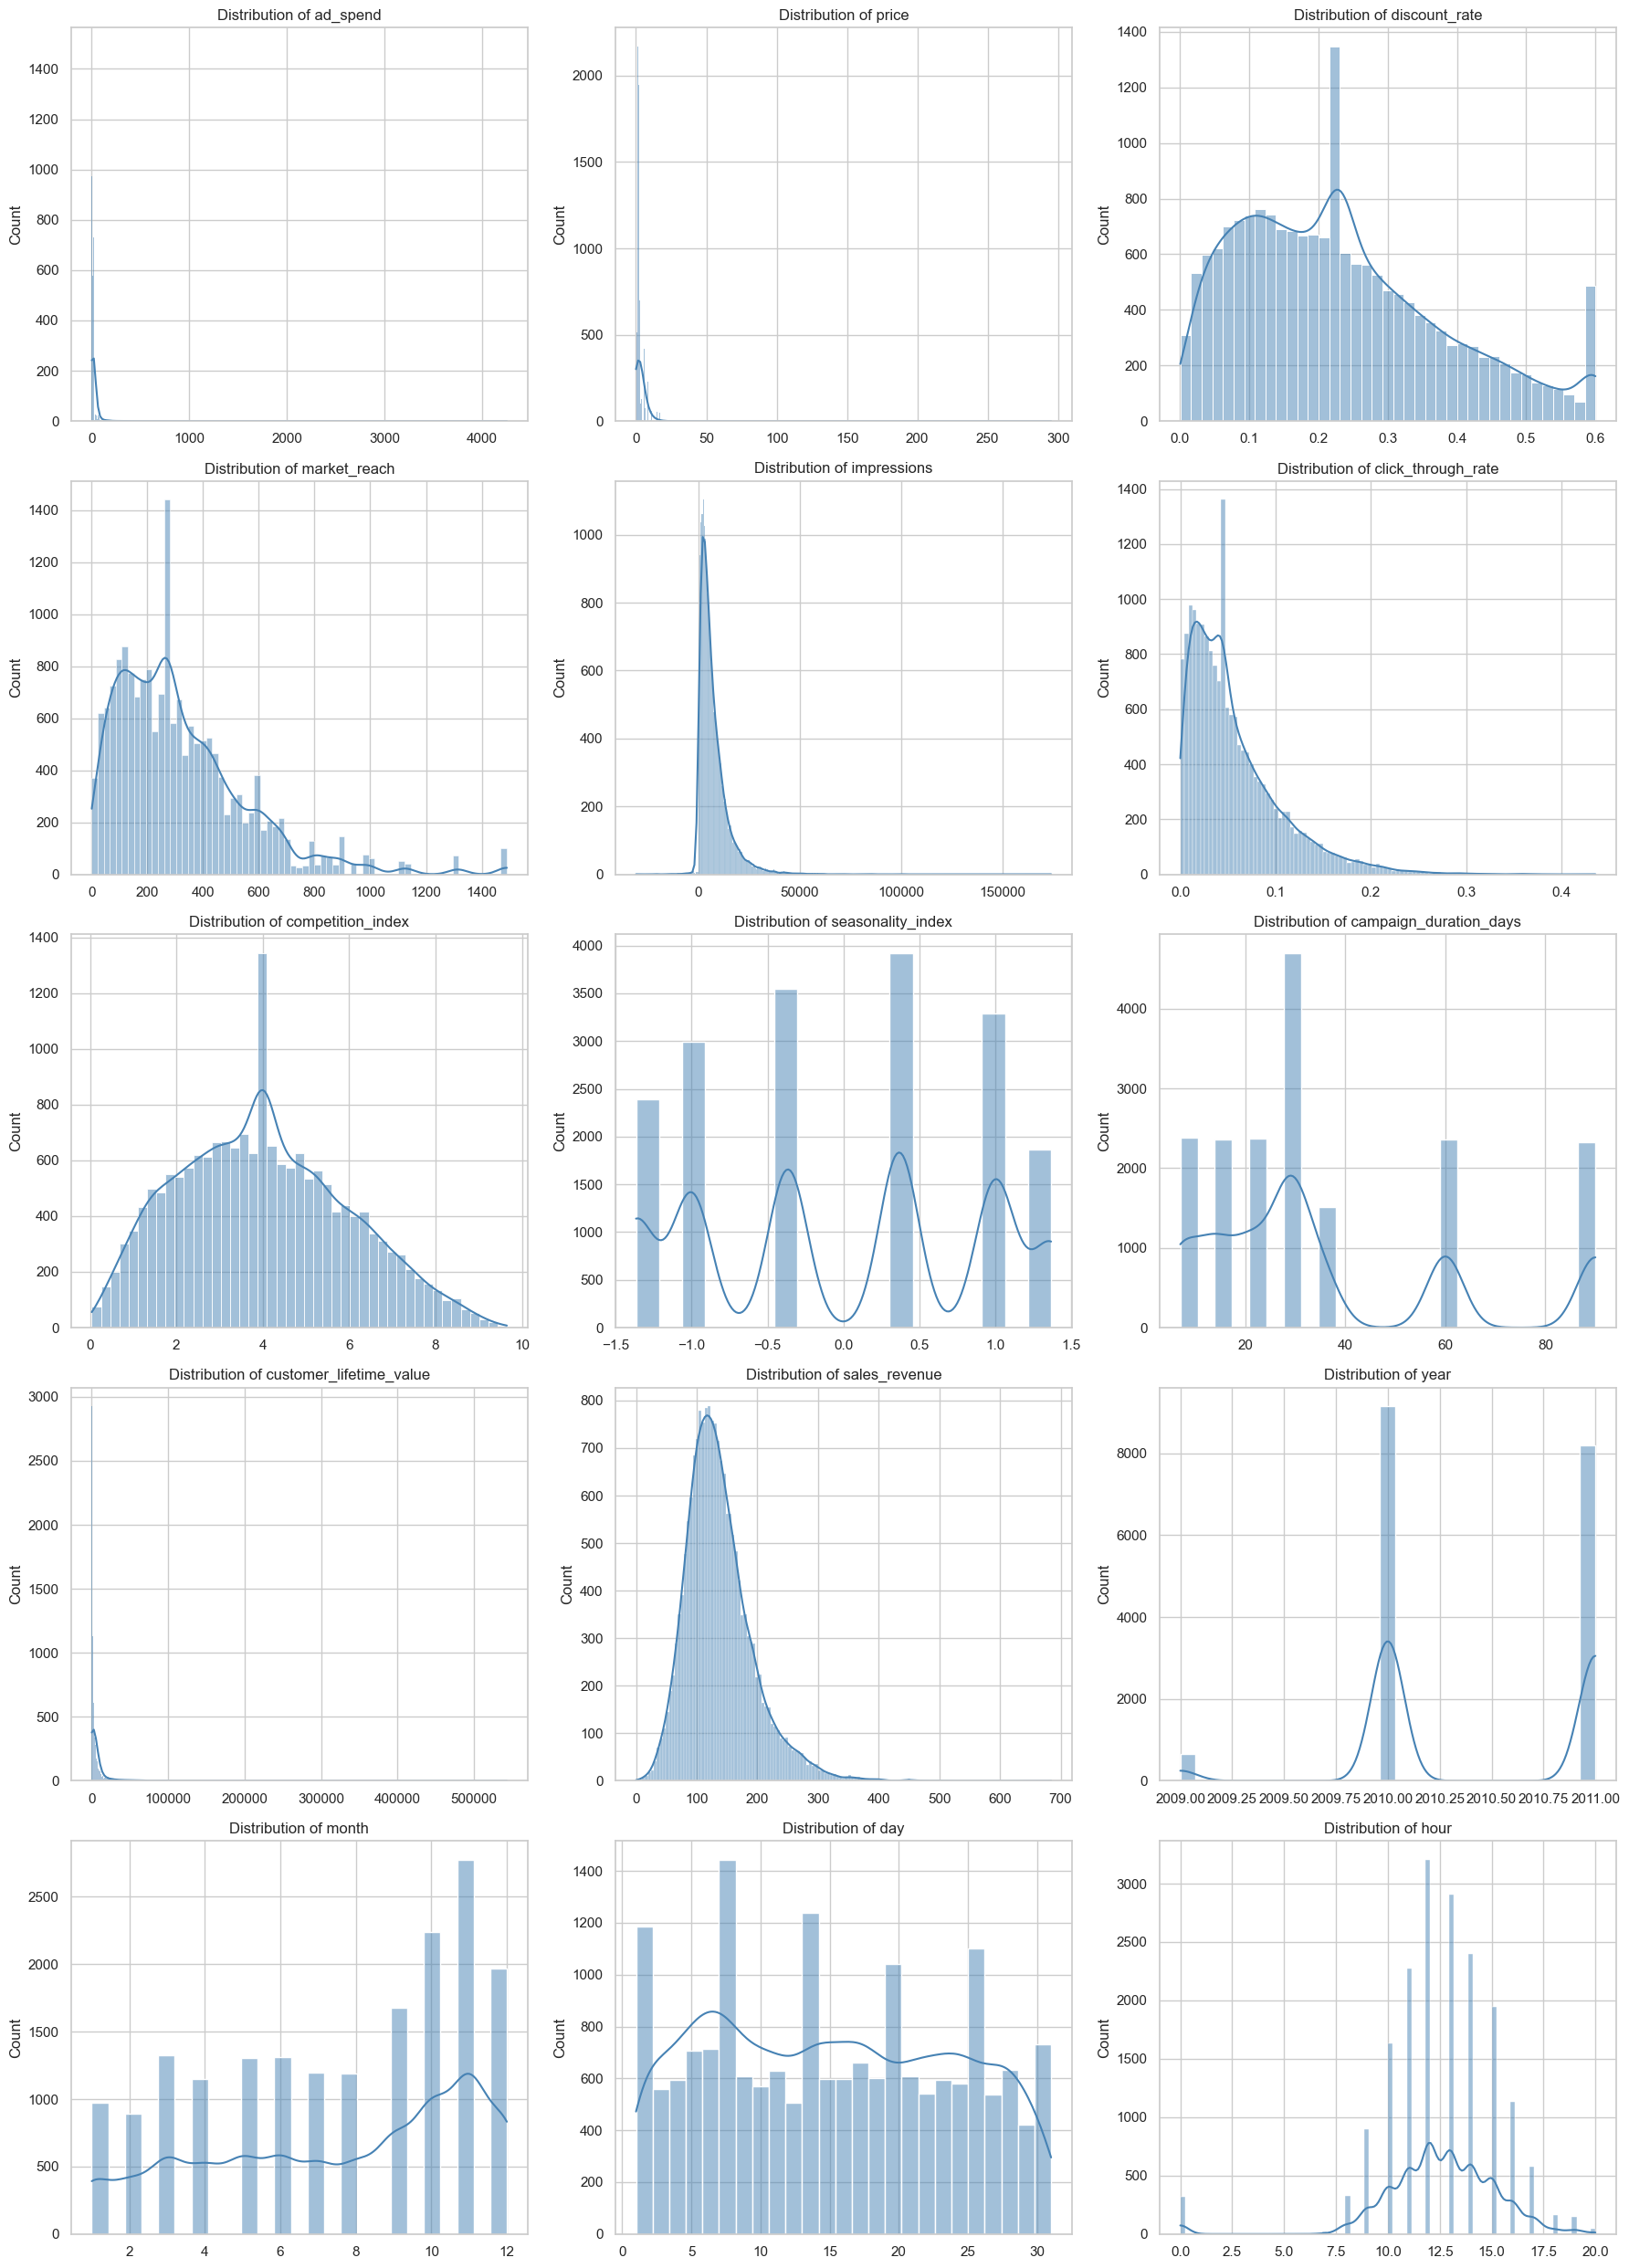

In [30]:
# Create subplots for all numerical variables
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Histogram with KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Numerical Variables - Boxplot (Outlier Analysis)

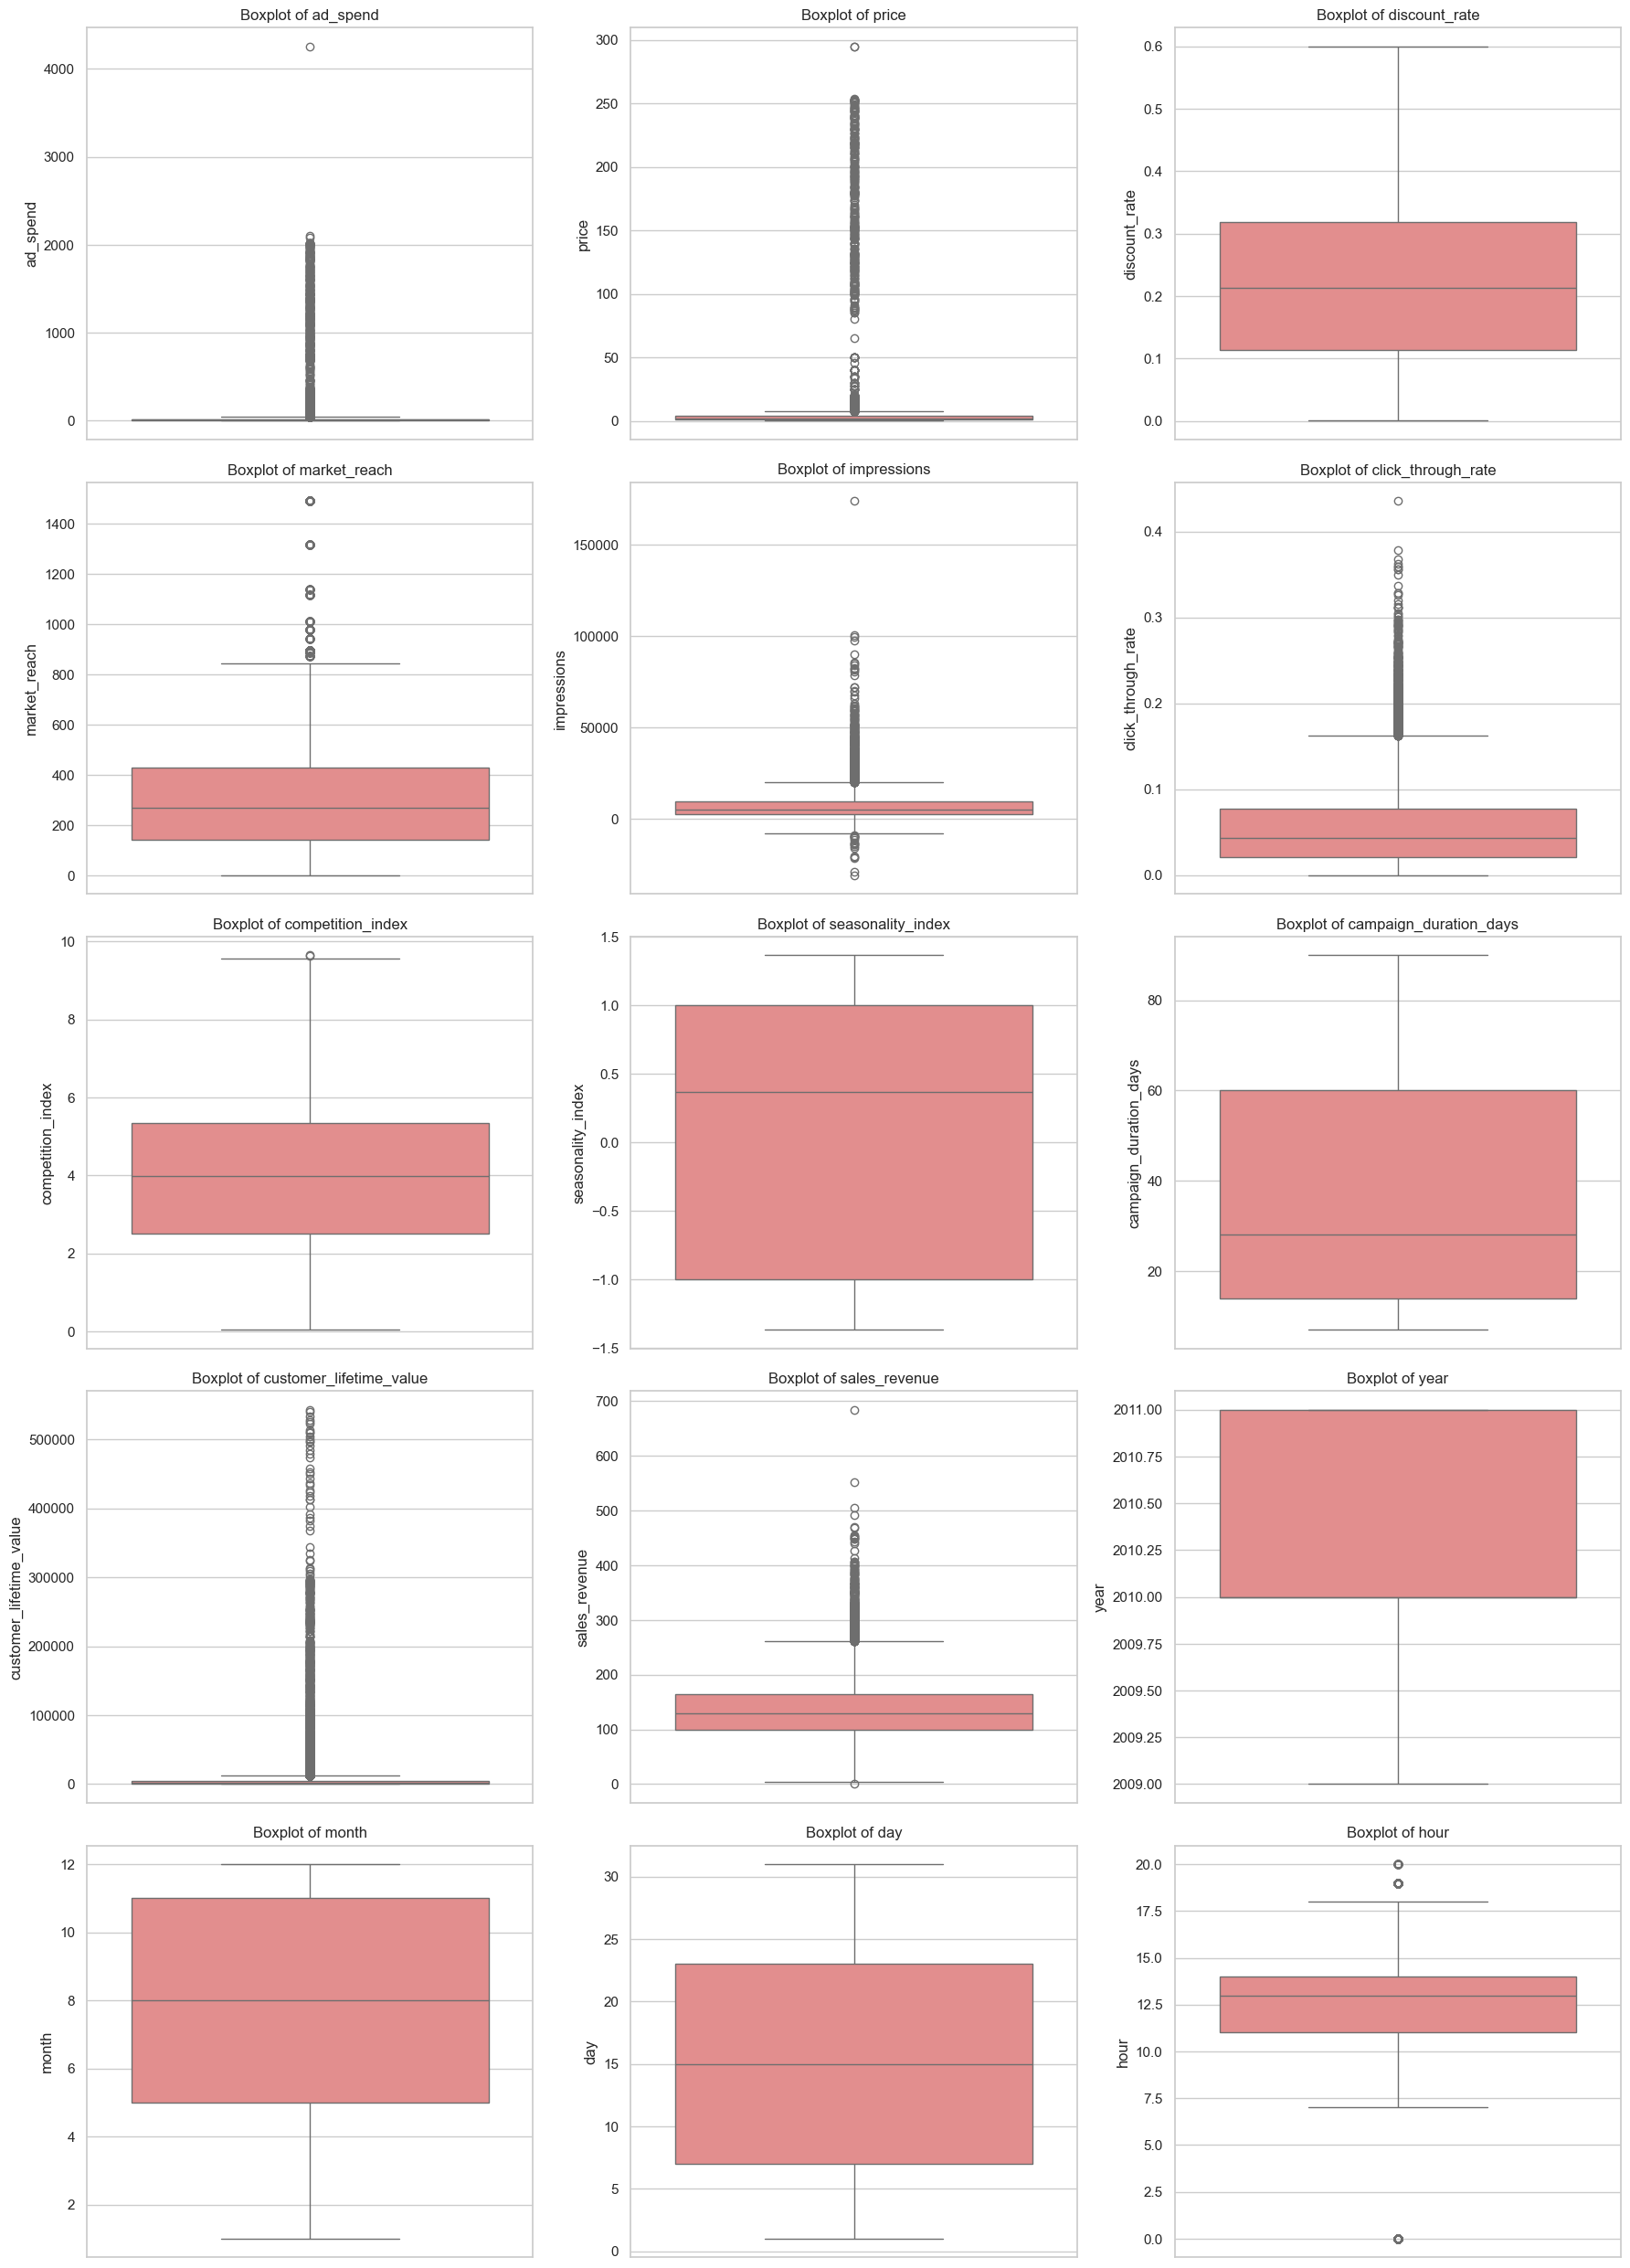

In [31]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Categorical Variables - Distribution

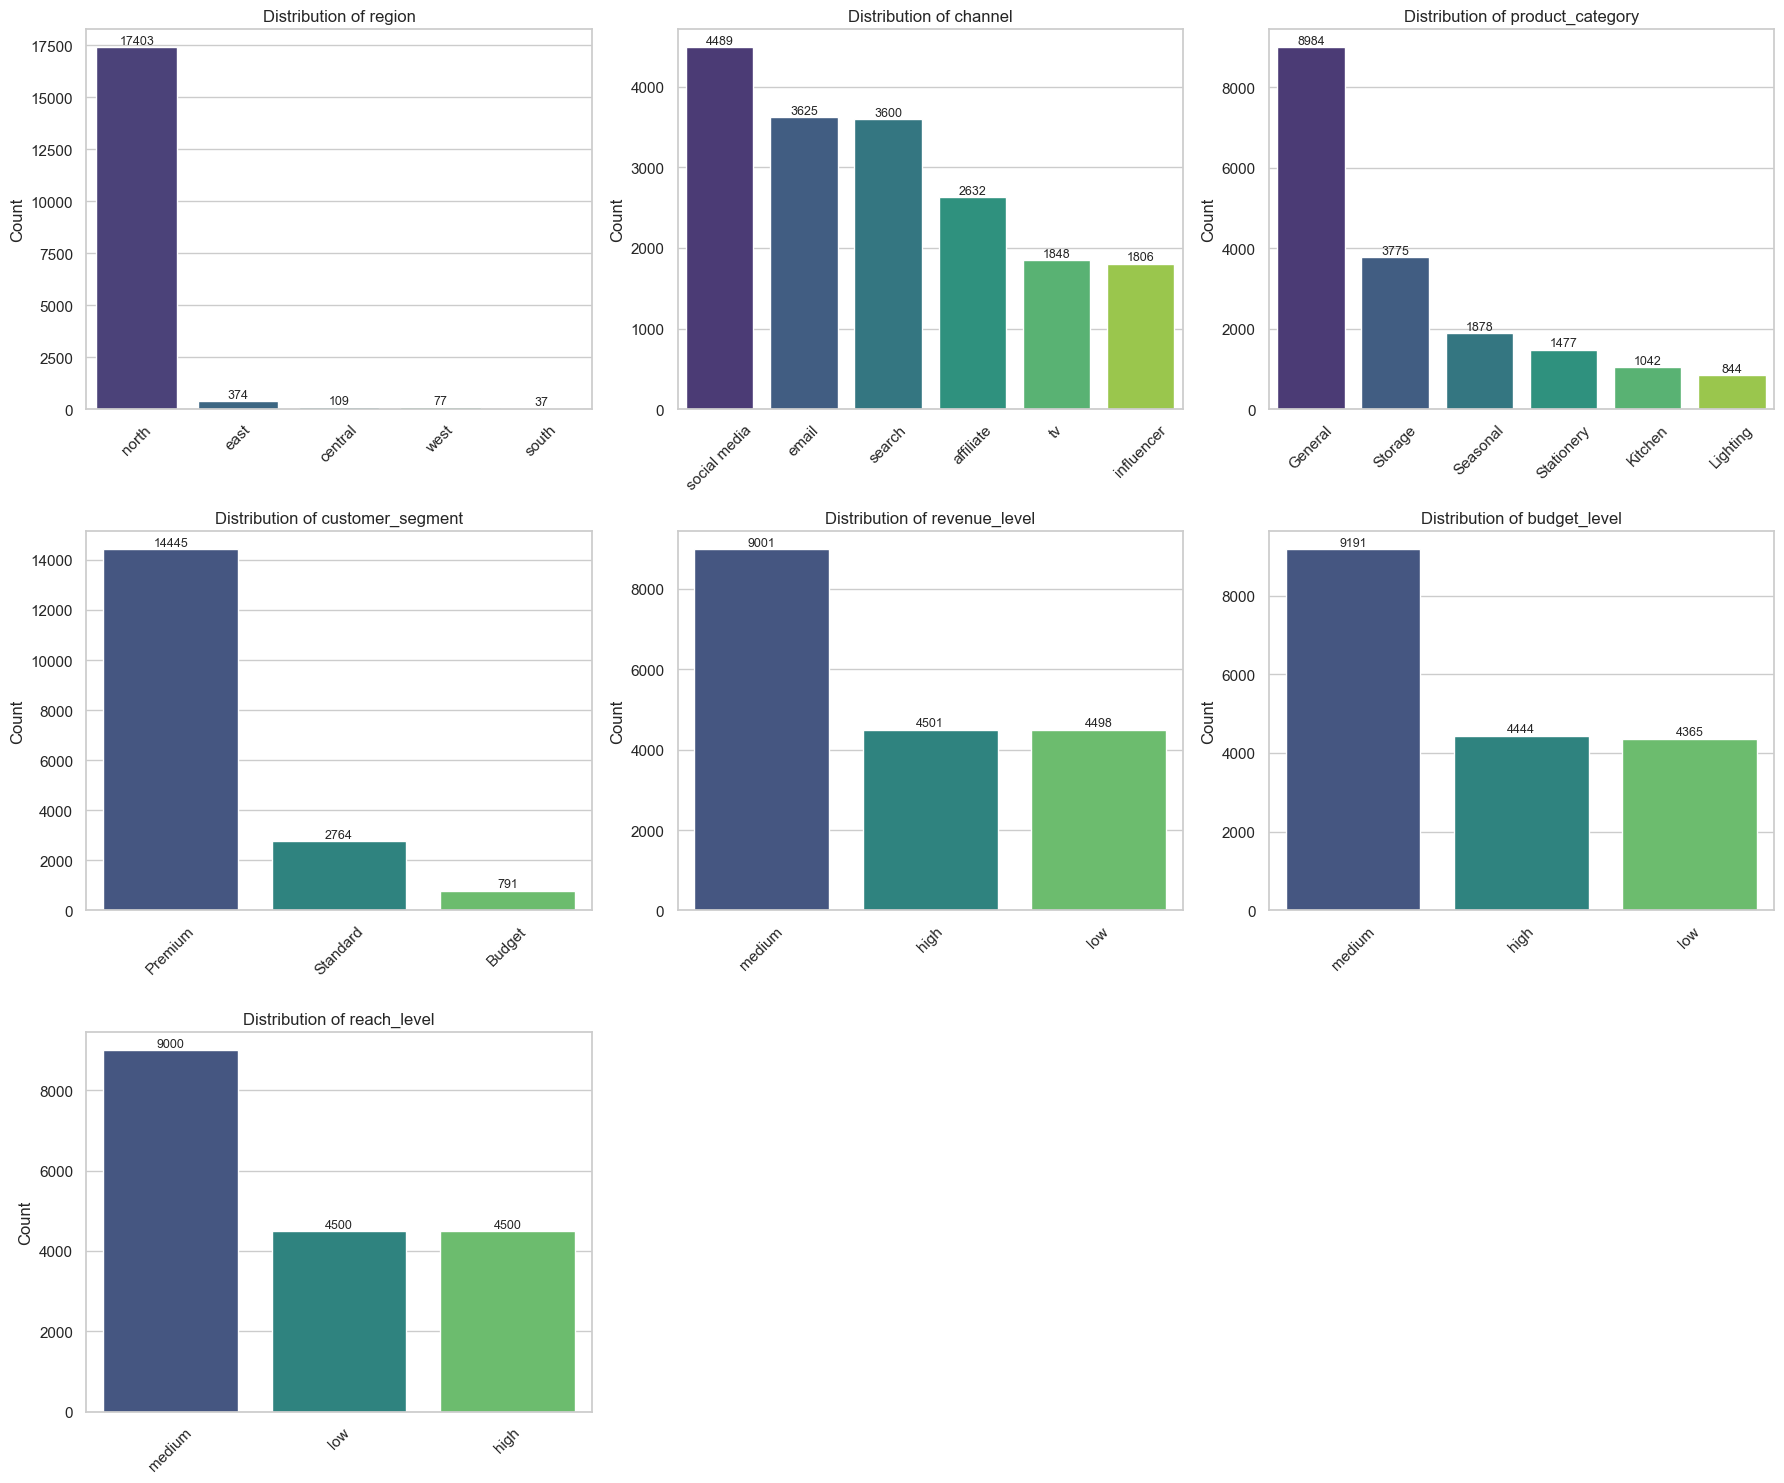


=== Category Percentages ===


REGION:
region
north      96.68
east        2.08
central     0.61
west        0.43
south       0.21
Name: proportion, dtype: float64

CHANNEL:
channel
social media    24.94
email           20.14
search          20.00
affiliate       14.62
tv              10.27
influencer      10.03
Name: proportion, dtype: float64

PRODUCT_CATEGORY:
product_category
General       49.91
Storage       20.97
Seasonal      10.43
Stationery     8.21
Kitchen        5.79
Lighting       4.69
Name: proportion, dtype: float64

CUSTOMER_SEGMENT:
customer_segment
Premium     80.25
Standard    15.36
Budget       4.39
Name: proportion, dtype: float64

REVENUE_LEVEL:
revenue_level
medium    50.01
high      25.01
low       24.99
Name: proportion, dtype: float64

BUDGET_LEVEL:
budget_level
medium    51.06
high      24.69
low       24.25
Name: proportion, dtype: float64

REACH_LEVEL:
reach_level
medium    50.0
low       25.0
high      25.0
Name: proportion, dtype: float64


In [32]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    value_counts = df[col].value_counts()
    
    # Bar plot
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for j, v in enumerate(value_counts.values):
        axes[i].text(j, v + 5, str(v), ha='center', va='bottom', fontsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Print percentages
print("\n=== Category Percentages ===\n")
for col in cat_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts(normalize=True).round(4) * 100)

## Target Variable Analysis (Sales Revenue)

=== Sales Revenue by Revenue Level ===
                 mean  count     min     max
revenue_level                               
high           210.95   4501  164.69  684.32
low             77.72   4498    0.00  100.06
medium         130.06   9001  100.09  164.66


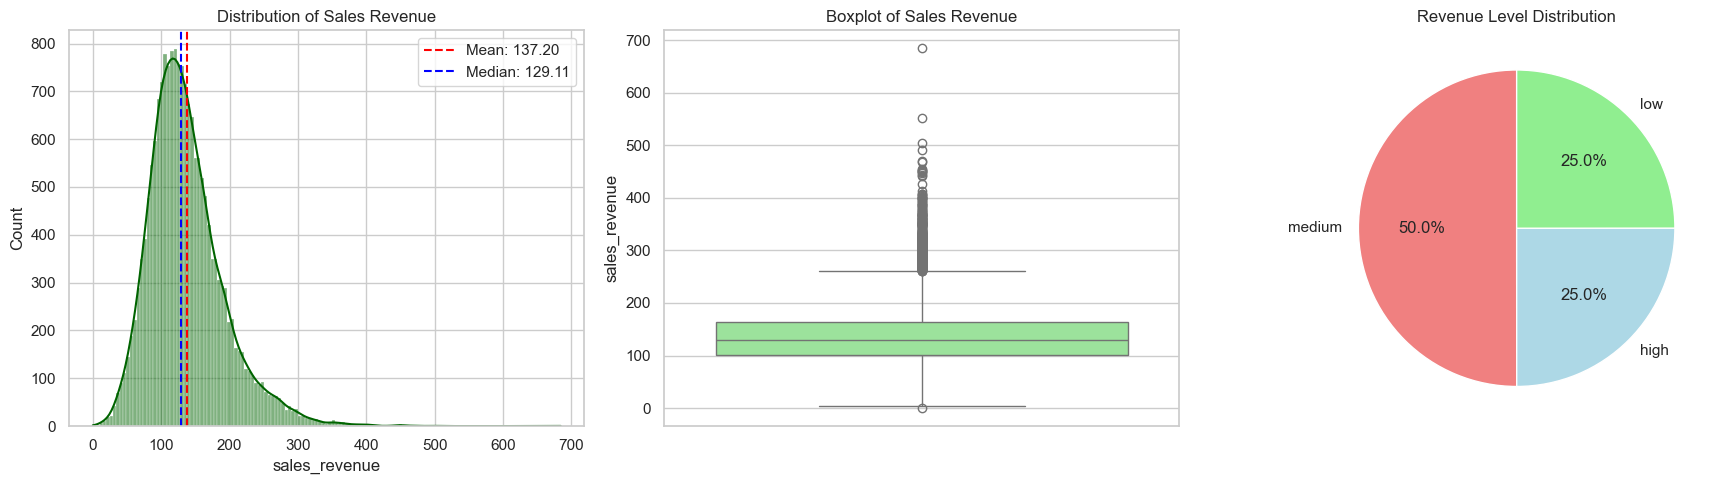

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
sns.histplot(data=df, x='sales_revenue', kde=True, ax=axes[0], color='darkgreen')
axes[0].set_title('Distribution of Sales Revenue')
axes[0].axvline(df['sales_revenue'].mean(), color='red', linestyle='--', label=f'Mean: {df["sales_revenue"].mean():.2f}')
axes[0].axvline(df['sales_revenue'].median(), color='blue', linestyle='--', label=f'Median: {df["sales_revenue"].median():.2f}')
axes[0].legend()

# Boxplot
sns.boxplot(data=df, y='sales_revenue', ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Sales Revenue')

# Revenue by revenue_level (our created category)
revenue_stats = df.groupby('revenue_level')['sales_revenue'].agg(['mean', 'count', 'min', 'max']).round(2)
print("=== Sales Revenue by Revenue Level ===")
print(revenue_stats)

# Pie chart for revenue_level distribution
revenue_level_counts = df['revenue_level'].value_counts()
axes[2].pie(revenue_level_counts.values, labels=revenue_level_counts.index, autopct='%1.1f%%', 
            colors=['lightcoral', 'lightblue', 'lightgreen'], startangle=90)
axes[2].set_title('Revenue Level Distribution')

plt.tight_layout()
plt.show()

## 2. BIVARIATE ANALYSIS (Two Variables Relationship)

## Numerical vs Numerical - Correlation Analysis

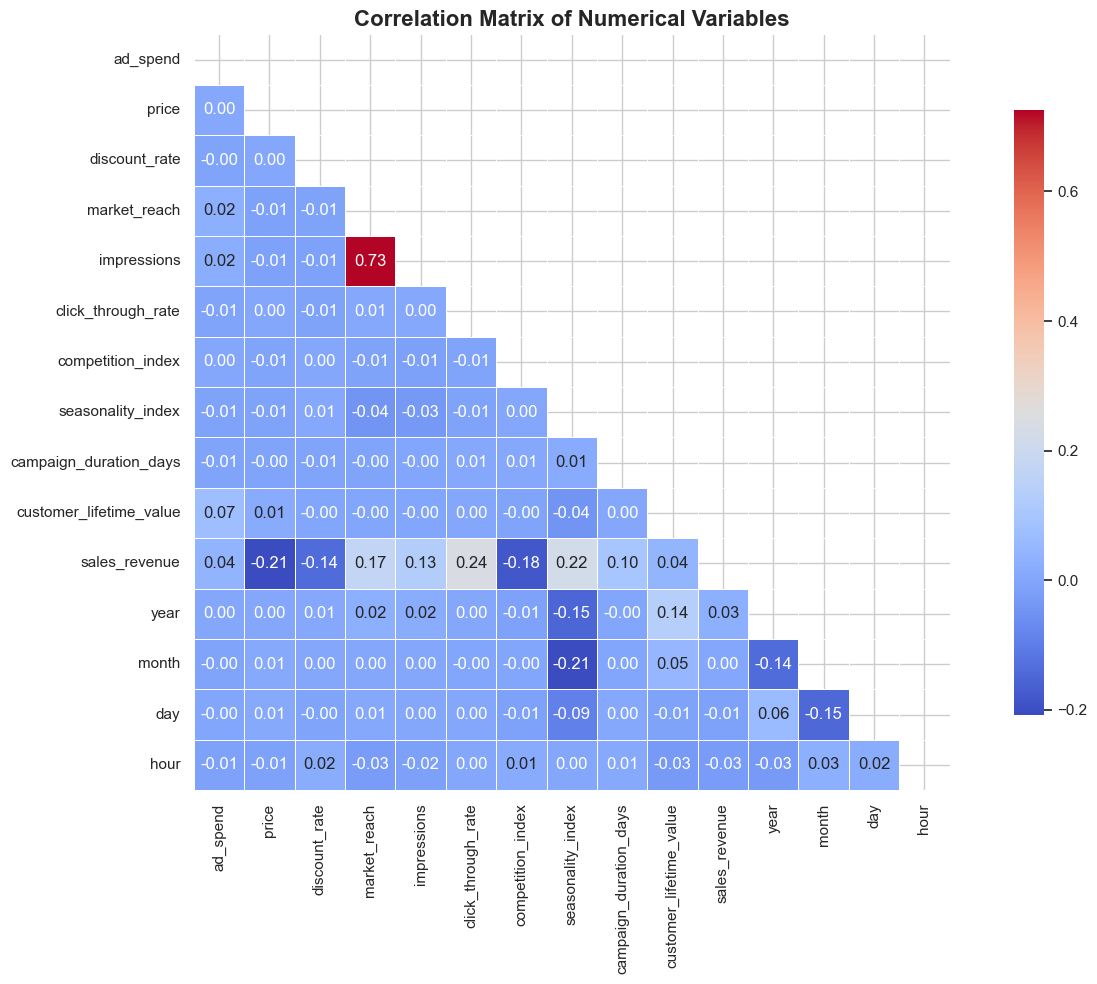


=== Top Correlations with Sales Revenue ===

sales_revenue              1.000000
click_through_rate         0.242433
seasonality_index          0.221127
market_reach               0.173273
impressions                0.128499
campaign_duration_days     0.098113
customer_lifetime_value    0.041493
ad_spend                   0.039323
year                       0.029409
month                      0.003006
day                       -0.011629
hour                      -0.025830
discount_rate             -0.141297
competition_index         -0.184412
price                     -0.205893
Name: sales_revenue, dtype: float64


In [34]:
# Calculate correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show top correlations with target
target_corr = corr_matrix['sales_revenue'].sort_values(ascending=False)
print("\n=== Top Correlations with Sales Revenue ===\n")
print(target_corr)

## Numerical vs Numerical - Scatter Plots

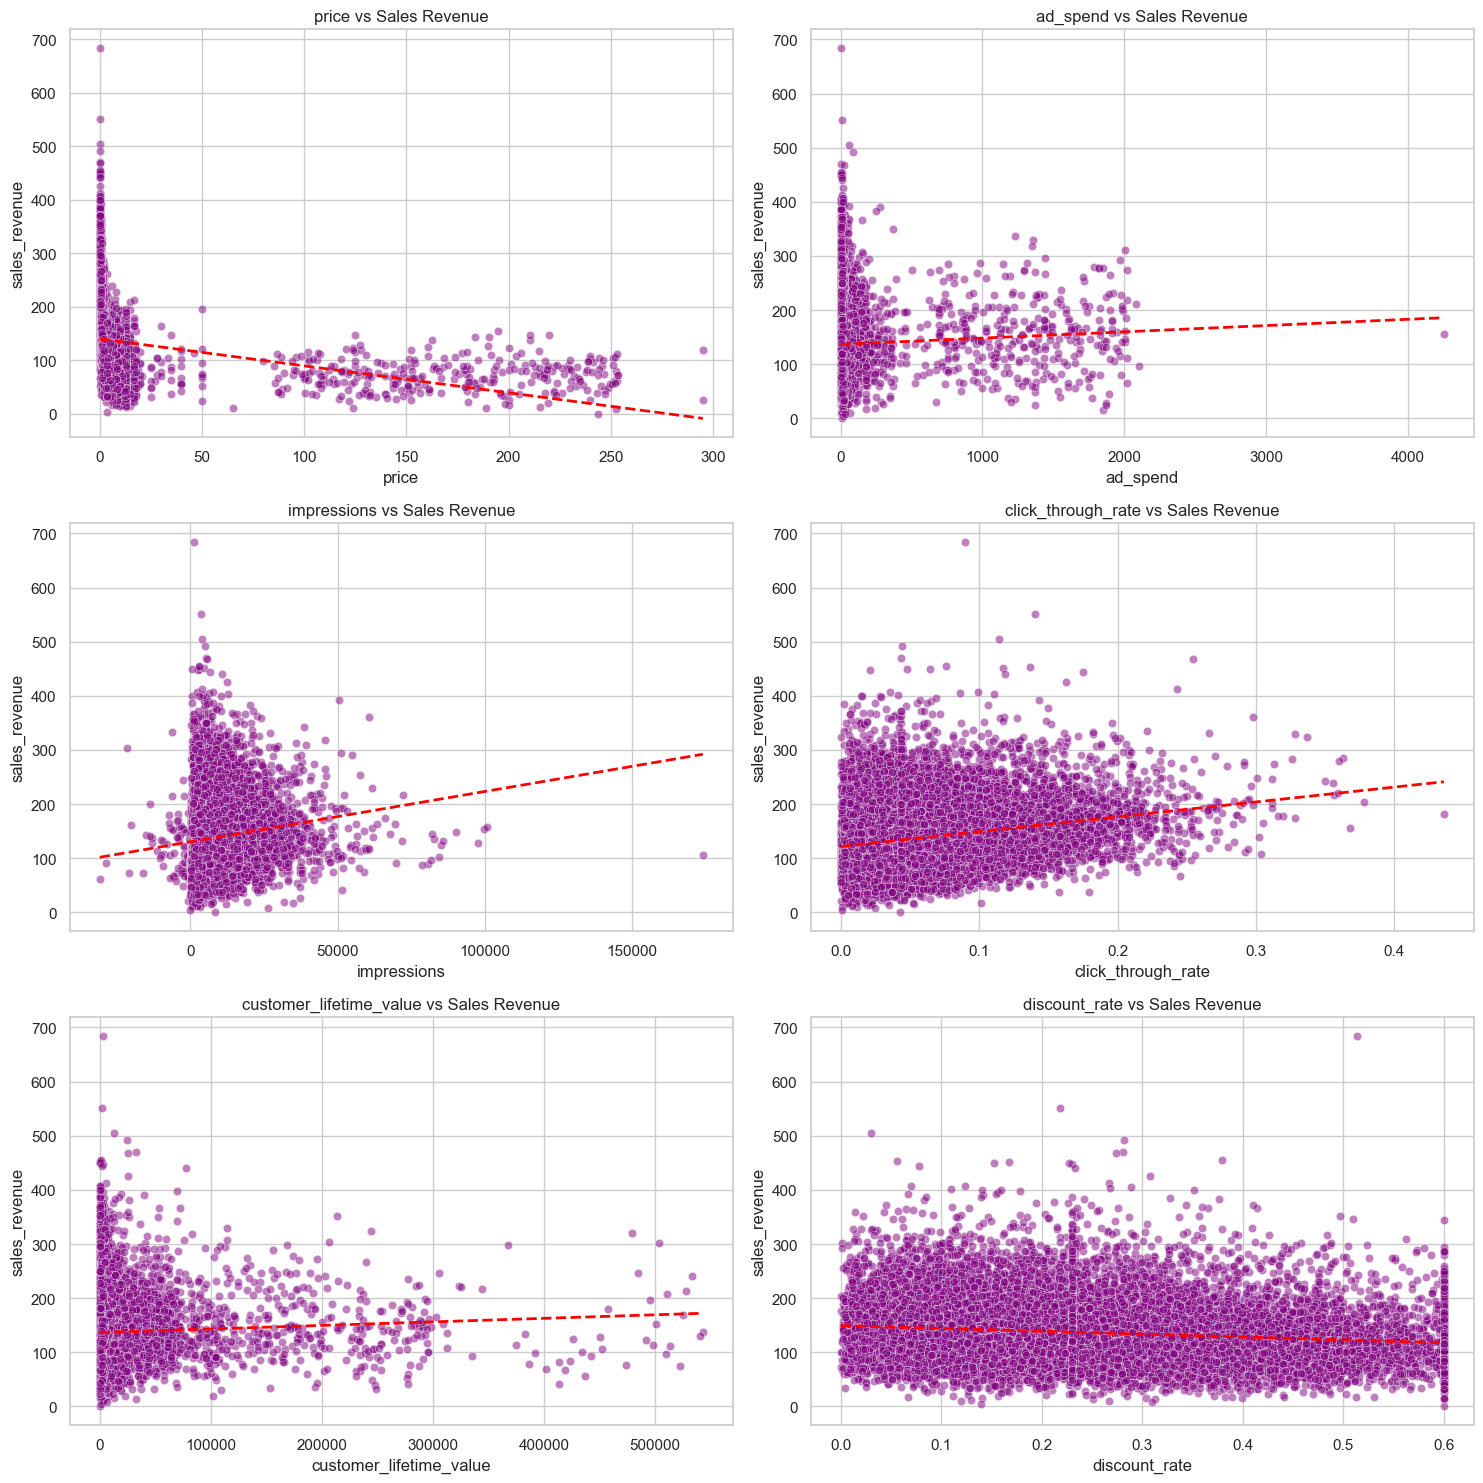

In [35]:
# Select important numerical features (top correlated with target)
important_features = ['price', 'ad_spend', 'impressions', 'click_through_rate', 
                      'customer_lifetime_value', 'discount_rate']

n_cols = 2
n_rows = (len(important_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(important_features):
    sns.scatterplot(data=df, x=feature, y='sales_revenue', ax=axes[i], alpha=0.5, color='purple')
    axes[i].set_title(f'{feature} vs Sales Revenue', fontsize=12)
    
    # Add trend line
    z = np.polyfit(df[feature], df['sales_revenue'], 1)
    p = np.poly1d(z)
    axes[i].plot(df[feature].sort_values(), p(df[feature].sort_values()), 
                color='red', linestyle='--', linewidth=2)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Categorical vs Numerical - Boxplots

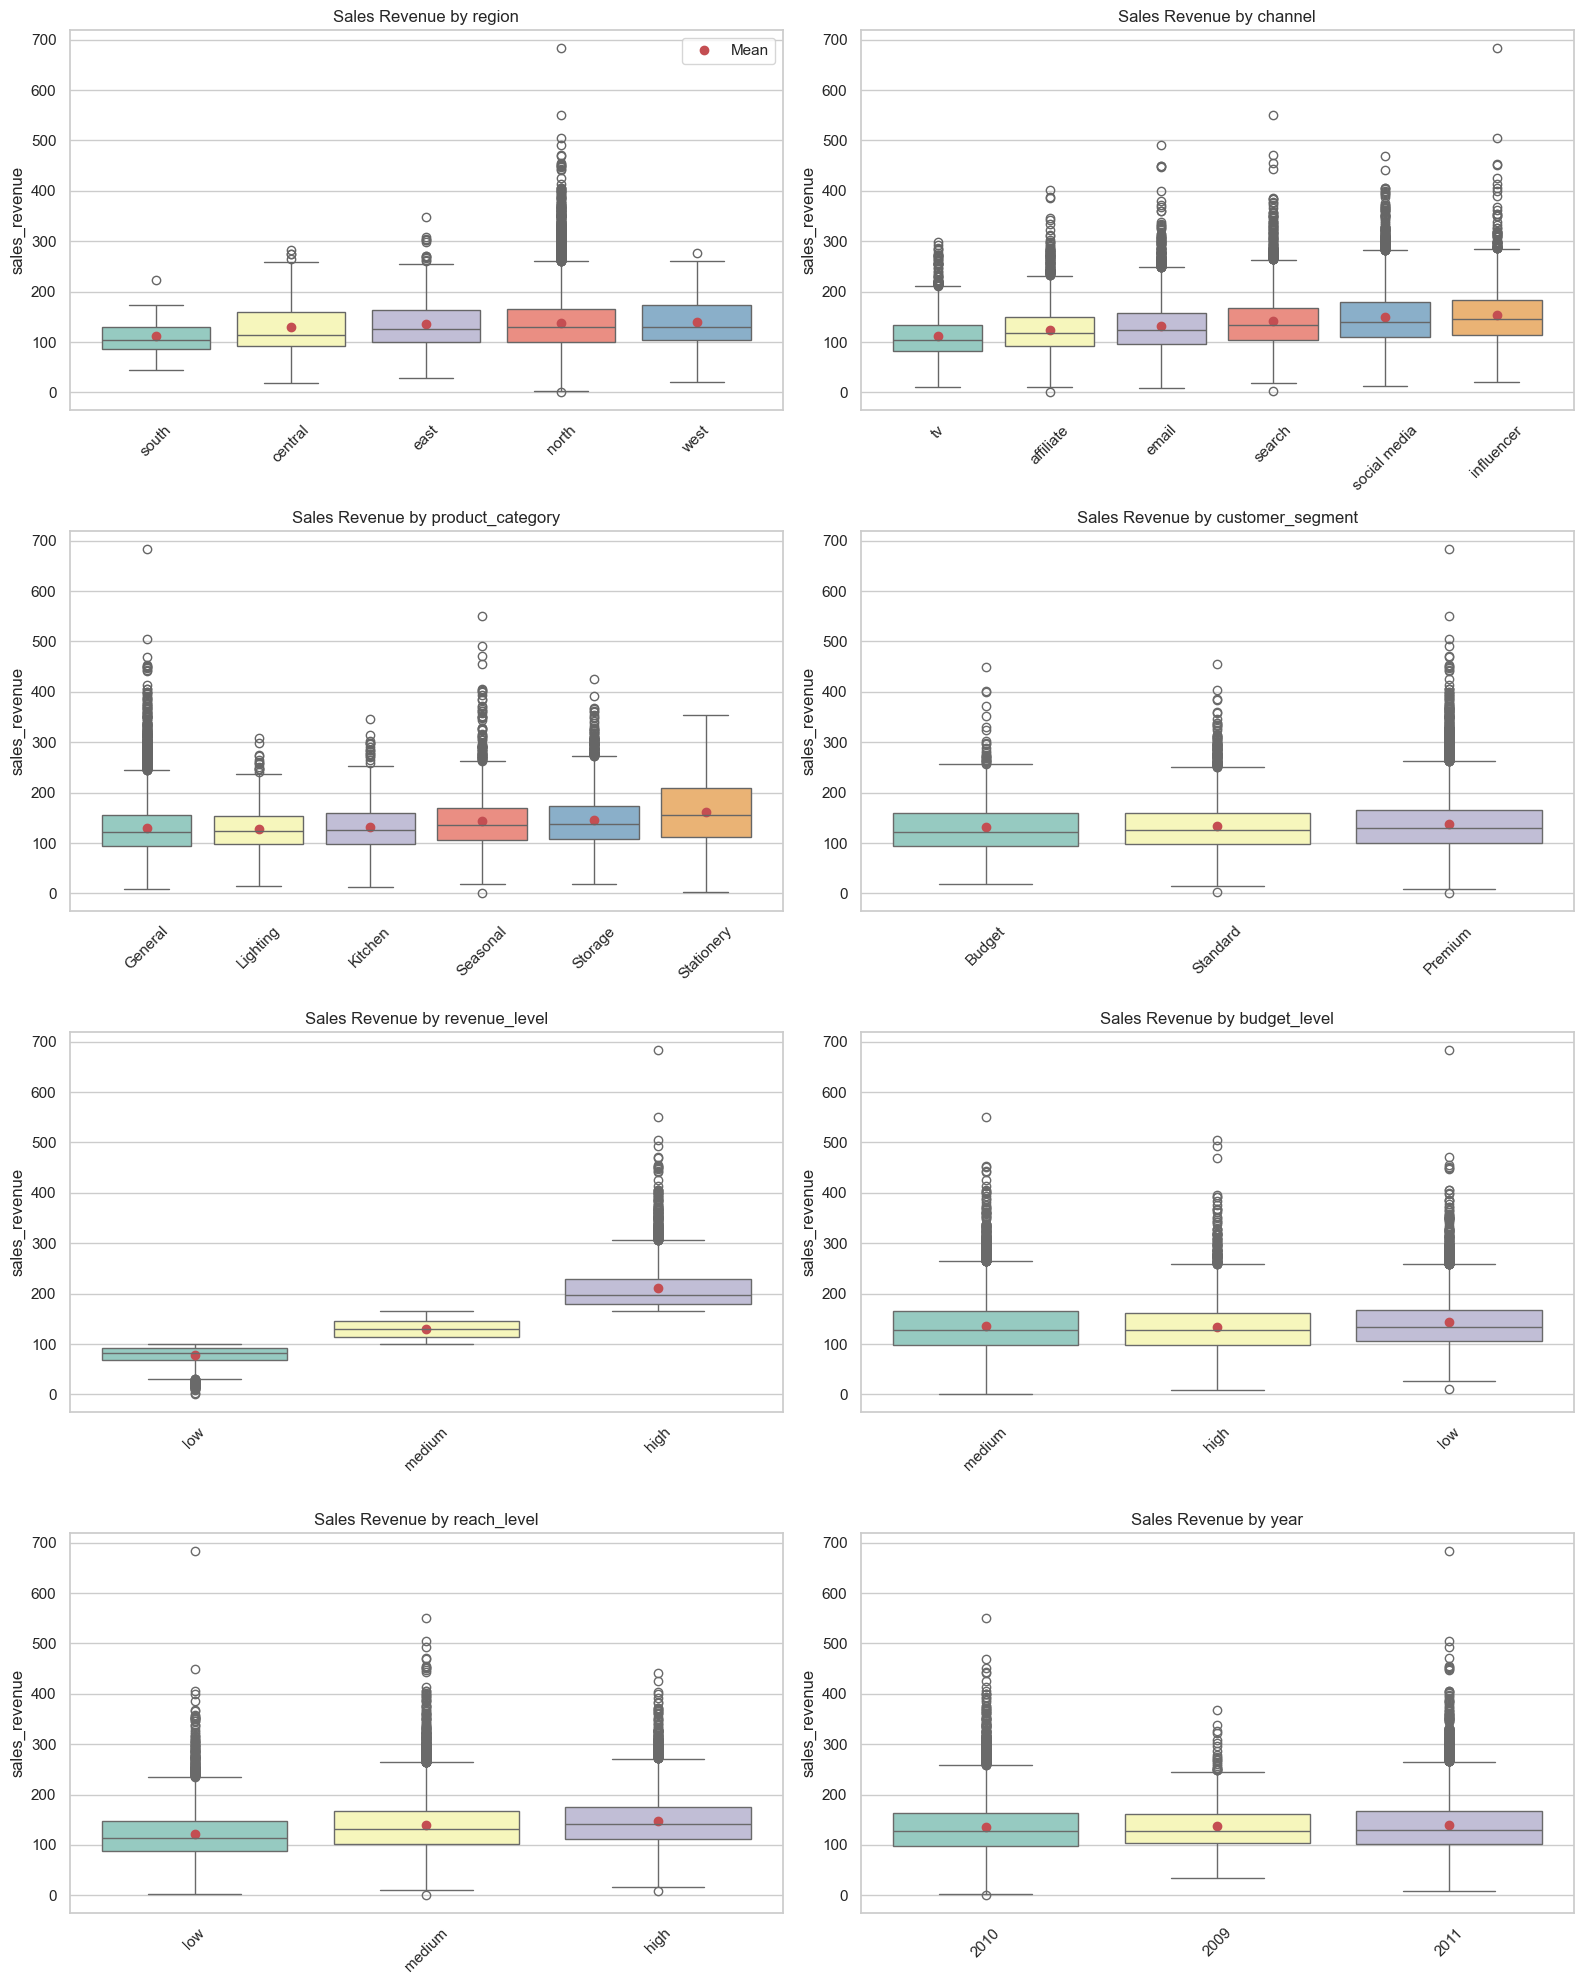

In [36]:
# For each categorical variable, see its relationship with sales revenue
cat_features = ['region', 'channel', 'product_category', 'customer_segment', 
                'revenue_level', 'budget_level', 'reach_level', 'year']

n_cols = 2
n_rows = (len(cat_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, cat in enumerate(cat_features):
    # Order by median sales revenue
    order = df.groupby(cat)['sales_revenue'].median().sort_values().index
    
    sns.boxplot(data=df, x=cat, y='sales_revenue', ax=axes[i], order=order, palette='Set3')
    axes[i].set_title(f'Sales Revenue by {cat}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add mean value as a point
    means = df.groupby(cat)['sales_revenue'].mean().reindex(order)
    axes[i].plot(range(len(means)), means.values, 'ro', markersize=6, label='Mean')
    
    if i == 0:
        axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3. MULTIVARIATE ANALYSIS (Multiple Variables Together)

## Pairplot of Important Variables

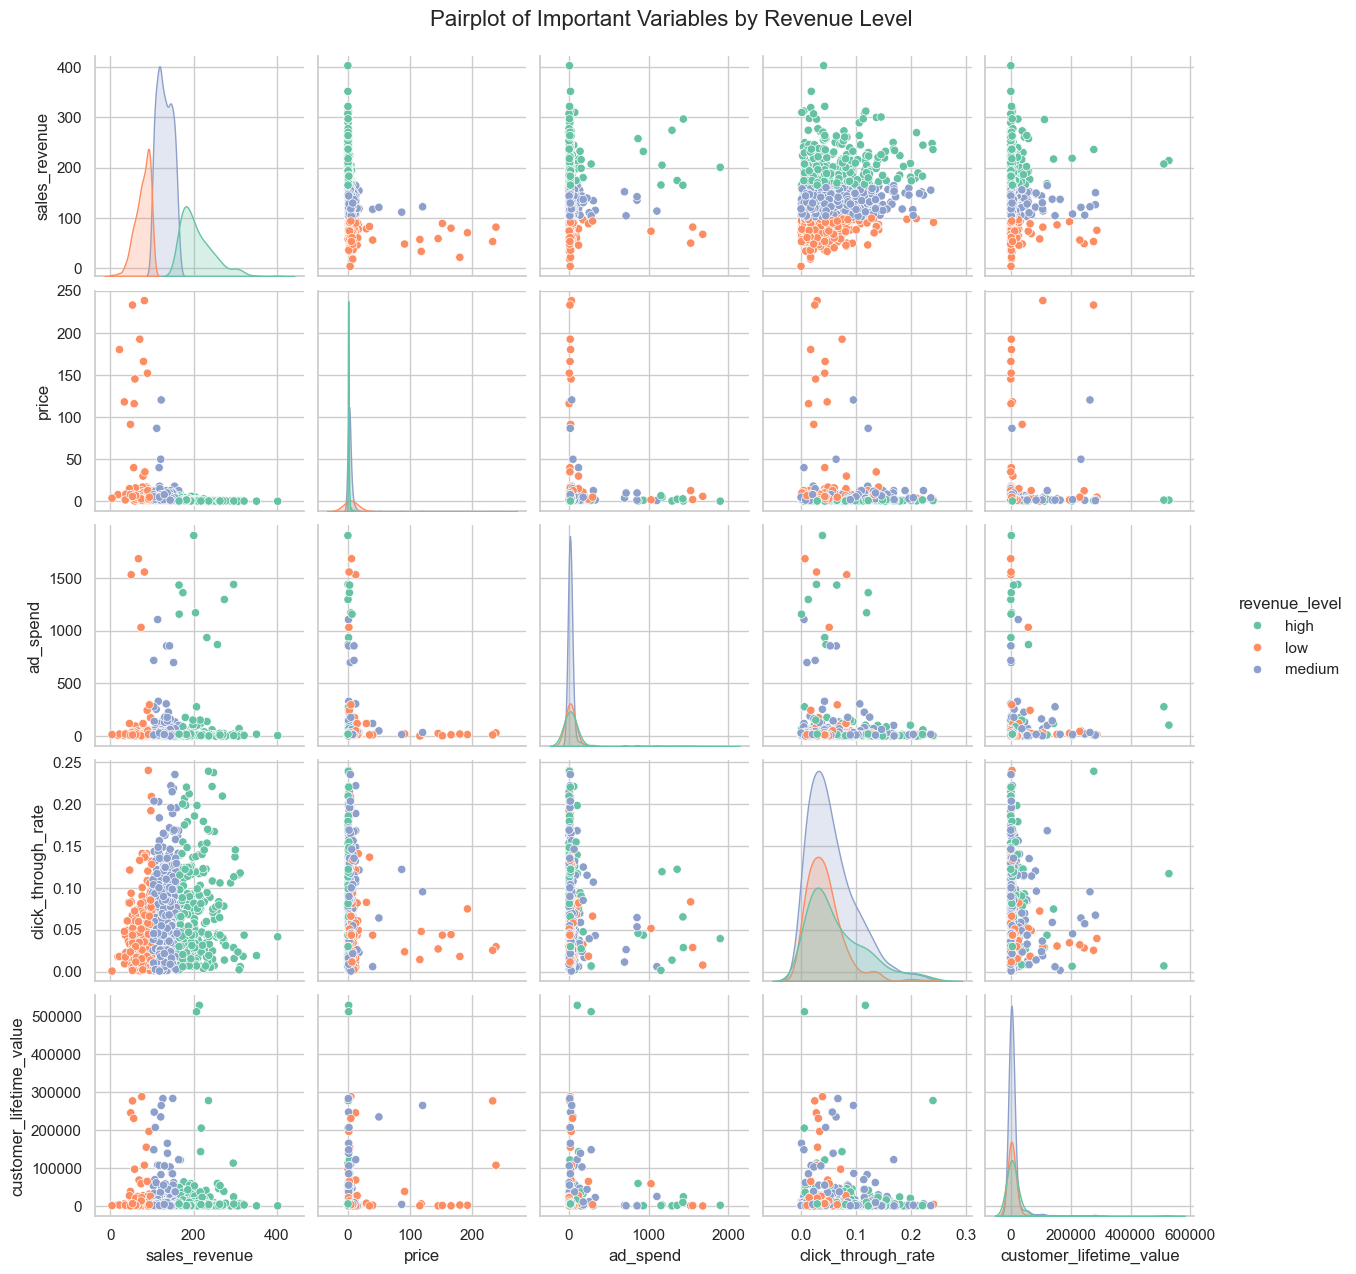

In [37]:
# Select important variables for pairplot
pairplot_vars = ['sales_revenue', 'price', 'ad_spend', 'click_through_rate', 
                 'customer_lifetime_value', 'revenue_level']

# Sample data for better visualization (if dataset is large)
sample_df = df.sample(min(1000, len(df)), random_state=42)

g = sns.pairplot(data=sample_df, vars=pairplot_vars[:-1], 
                 hue='revenue_level', palette='Set2', diag_kind='kde')
g.fig.suptitle('Pairplot of Important Variables by Revenue Level', y=1.02, fontsize=16)
plt.show()

## FacetGrid Analysis

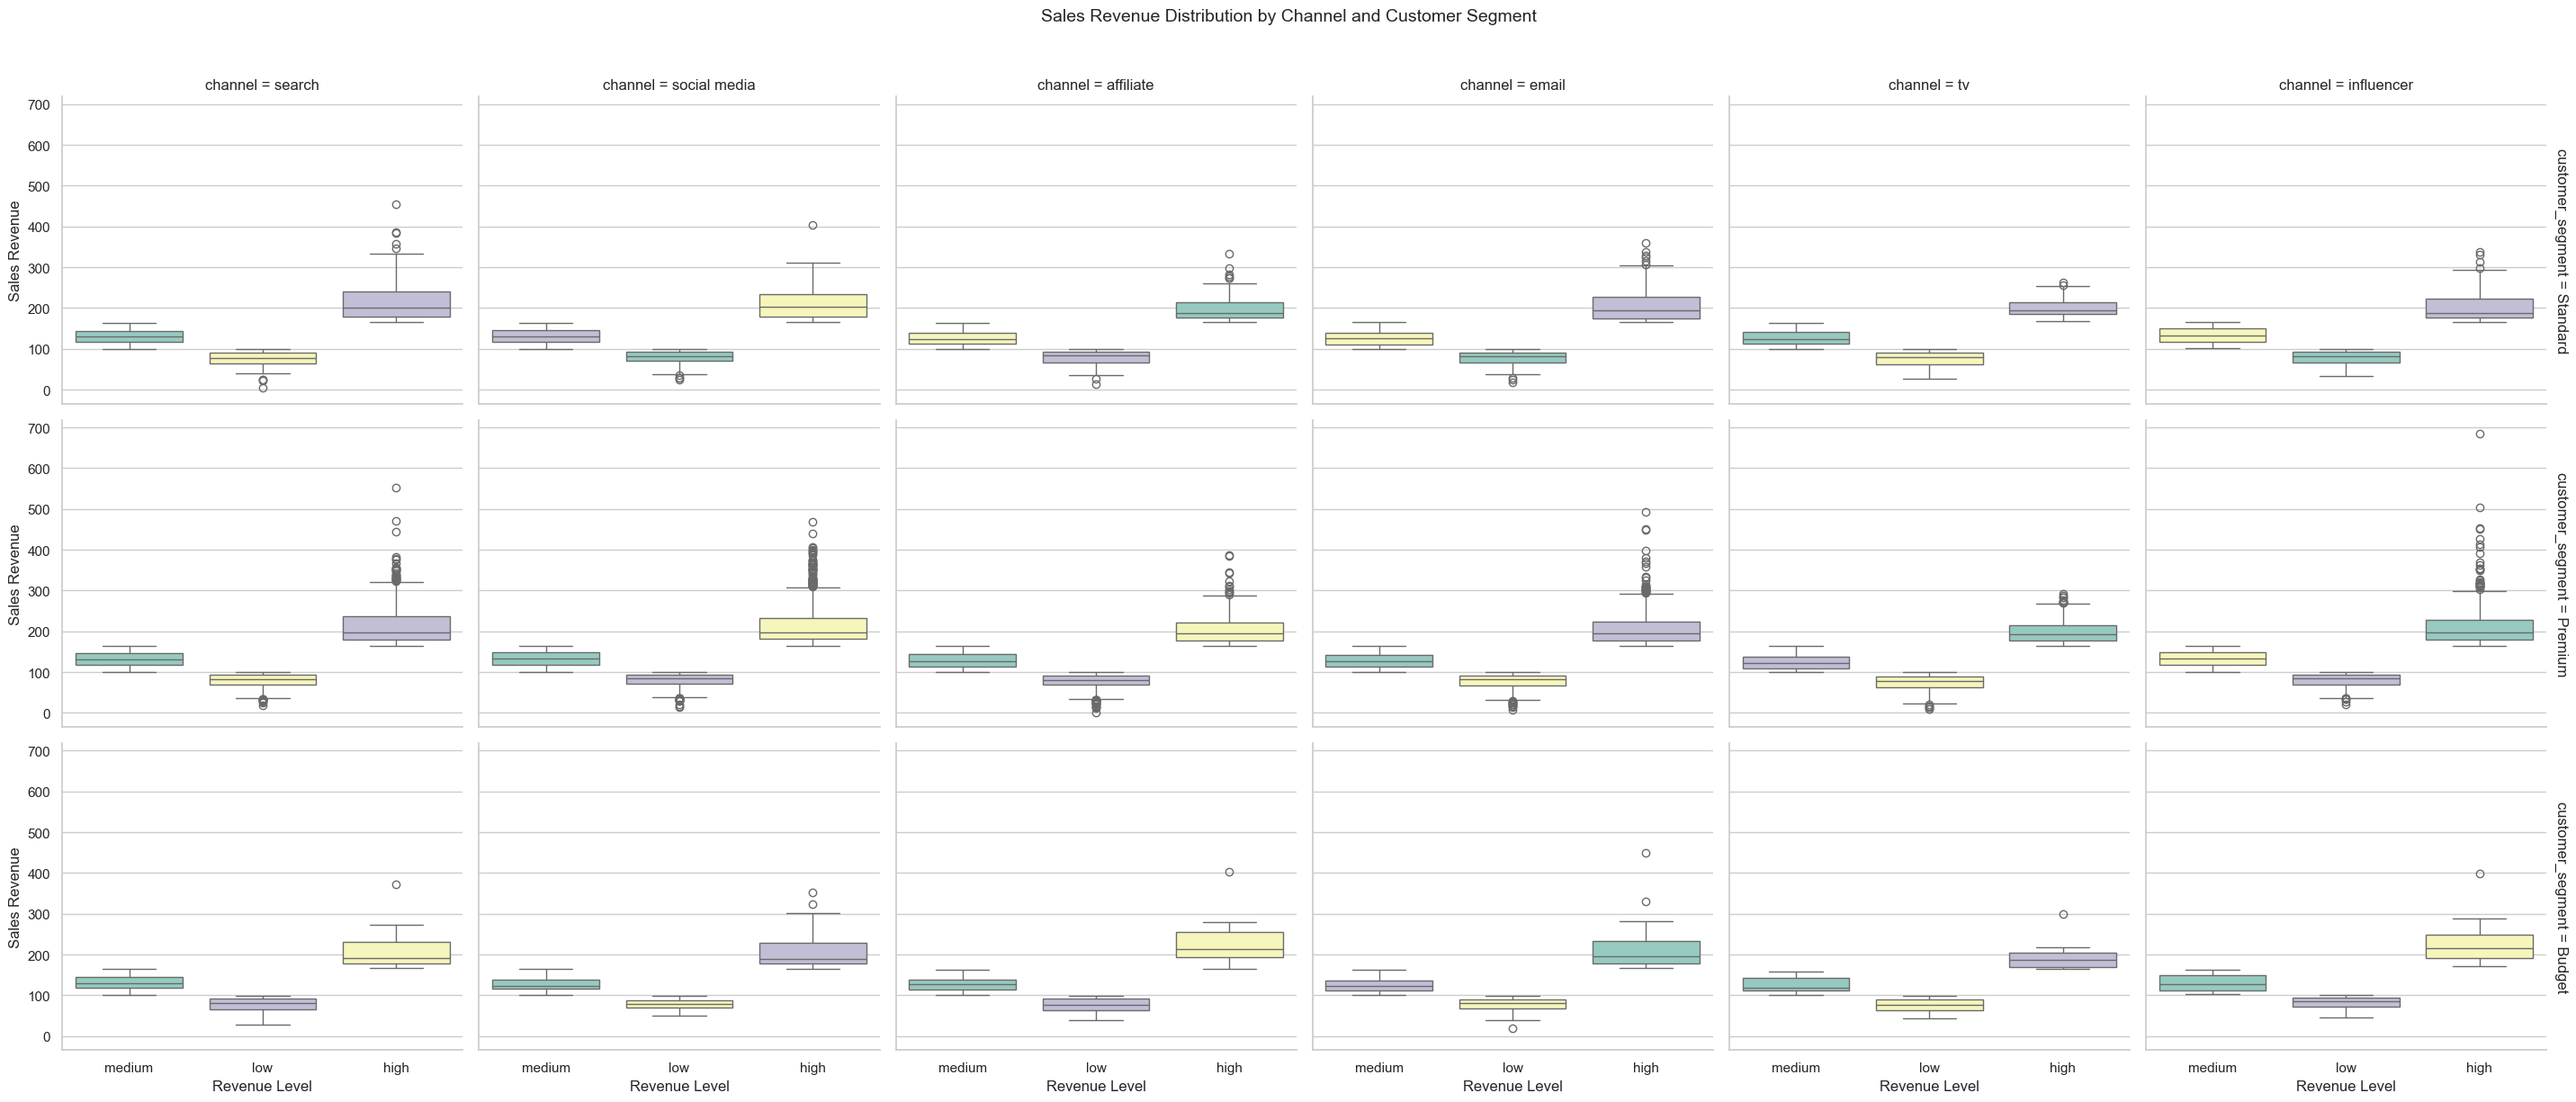

In [38]:
# Sales Revenue by Channel and Customer Segment
g = sns.FacetGrid(df, col='channel', row='customer_segment', 
                  height=4, aspect=1.2, margin_titles=True)
g.map_dataframe(sns.boxplot, x='revenue_level', y='sales_revenue', palette='Set3')
g.set_axis_labels('Revenue Level', 'Sales Revenue')
g.fig.suptitle('Sales Revenue Distribution by Channel and Customer Segment', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Clustered Bar Charts

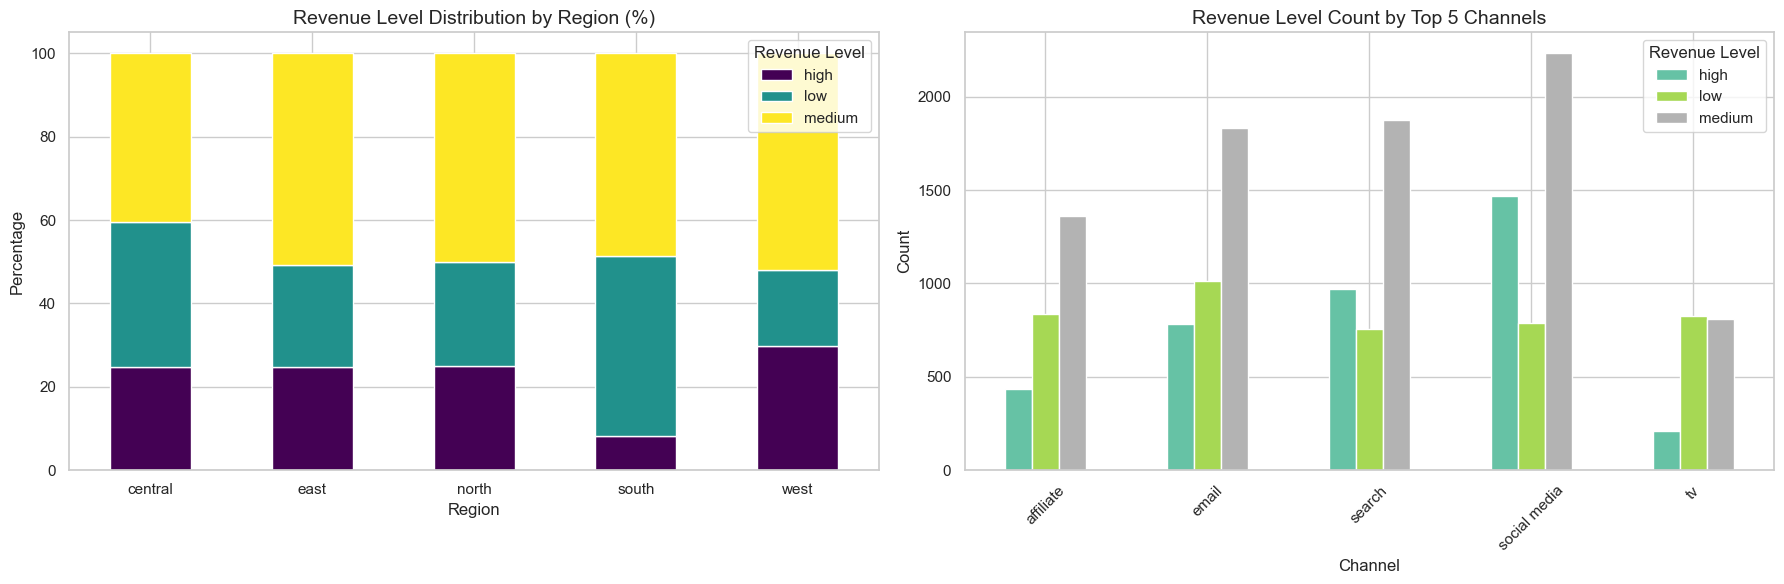

In [39]:
# Revenue Level distribution by Region and Customer Segment
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Stacked bar
revenue_region = pd.crosstab(df['region'], df['revenue_level'], normalize='index') * 100
revenue_region.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Revenue Level Distribution by Region (%)', fontsize=14)
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Percentage')
axes[0].legend(title='Revenue Level')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Grouped bar for top channels
top_channels = df['channel'].value_counts().nlargest(5).index
channel_df = df[df['channel'].isin(top_channels)]
revenue_channel = pd.crosstab(channel_df['channel'], channel_df['revenue_level'])
revenue_channel.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Revenue Level Count by Top 5 Channels', fontsize=14)
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Count')
axes[1].legend(title='Revenue Level')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. TIME SERIES ANALYSIS (If Date Features Exist)

## Sales Trends Over Time

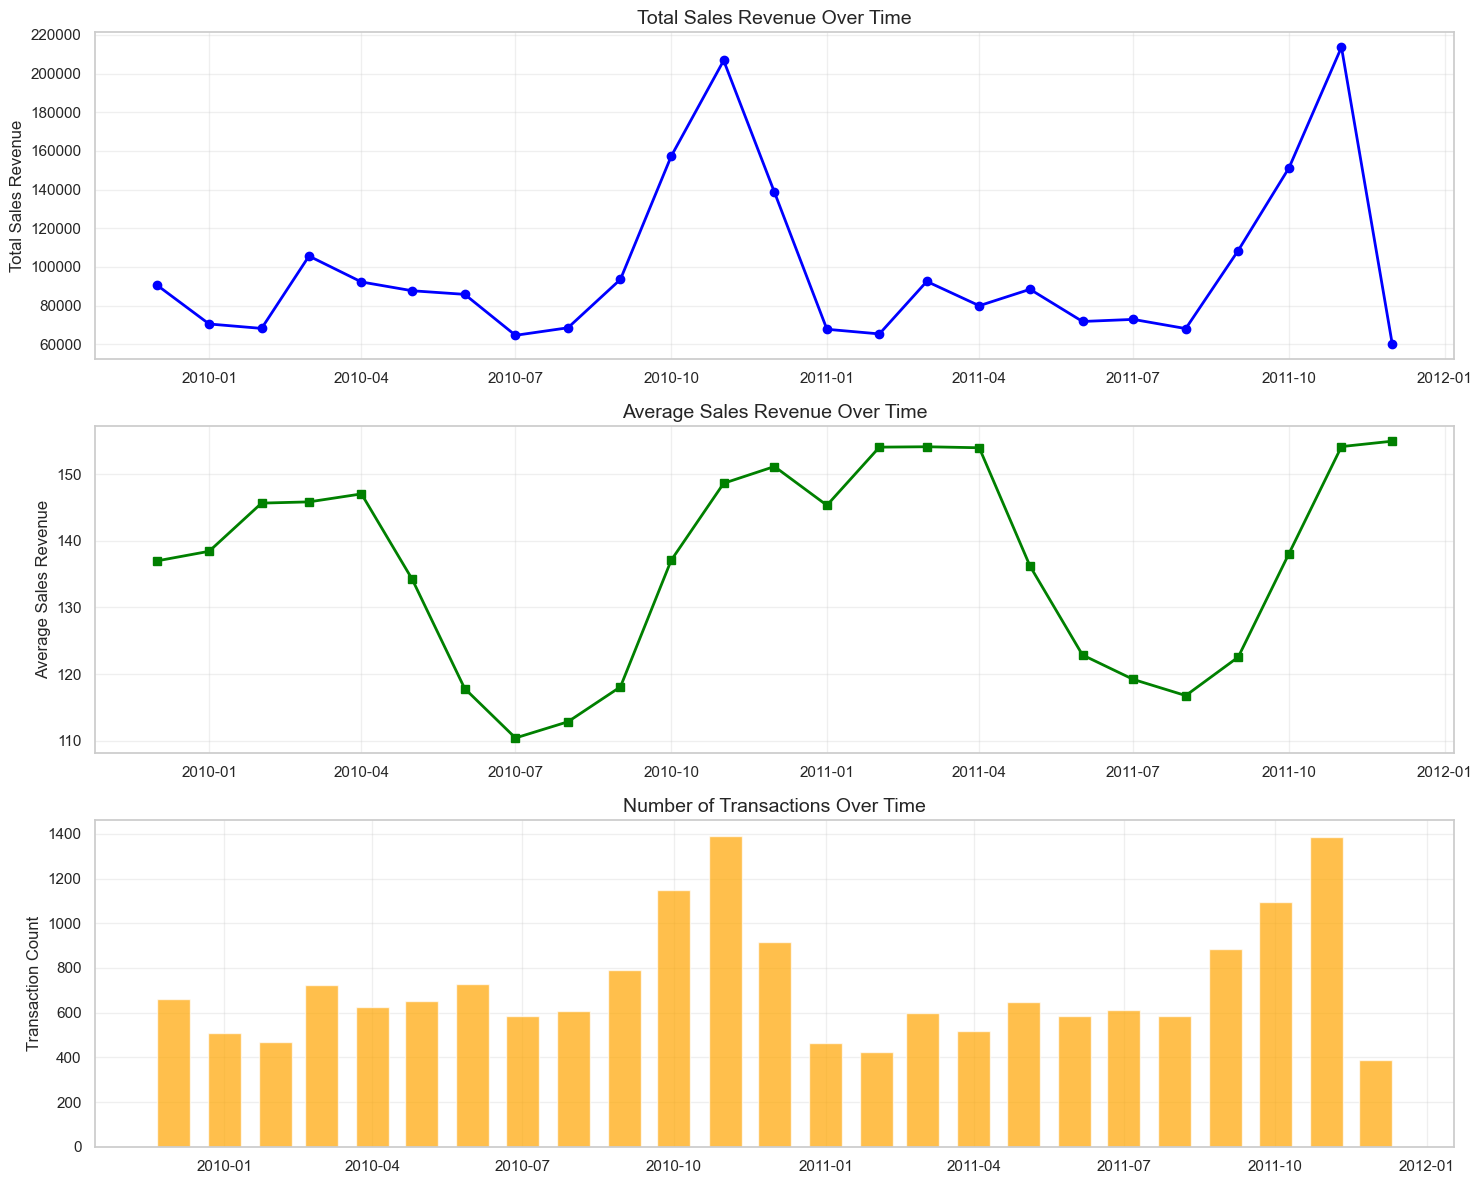

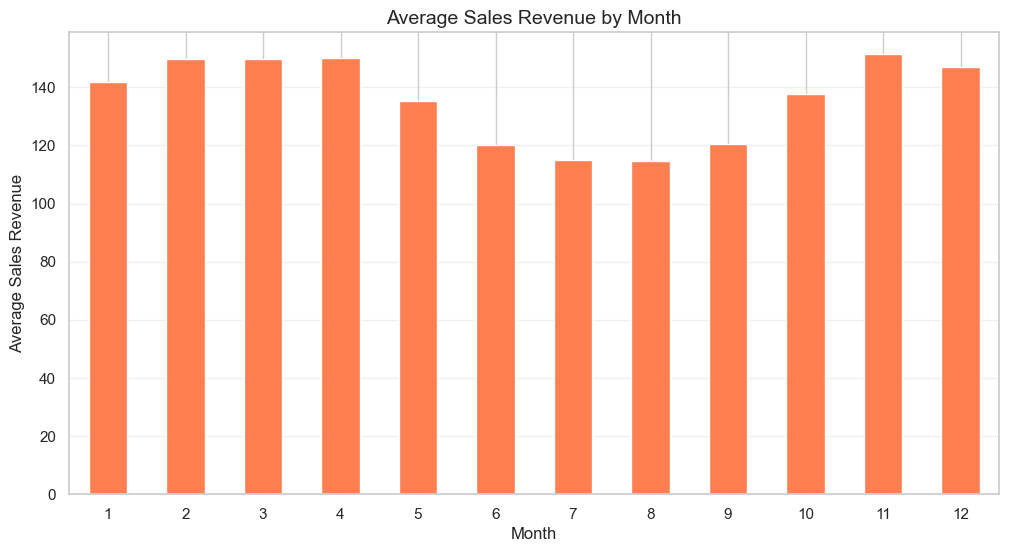

In [40]:
# Aggregate sales by year and month
if 'year' in df.columns and 'month' in df.columns:
    time_sales = df.groupby(['year', 'month'])['sales_revenue'].agg(['mean', 'sum', 'count']).reset_index()
    time_sales['date'] = pd.to_datetime(time_sales['year'].astype(str) + '-' + time_sales['month'].astype(str) + '-01')
    time_sales = time_sales.sort_values('date')
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Total sales over time
    axes[0].plot(time_sales['date'], time_sales['sum'], marker='o', color='blue', linewidth=2)
    axes[0].set_title('Total Sales Revenue Over Time', fontsize=14)
    axes[0].set_ylabel('Total Sales Revenue')
    axes[0].grid(True, alpha=0.3)
    
    # Average sales over time
    axes[1].plot(time_sales['date'], time_sales['mean'], marker='s', color='green', linewidth=2)
    axes[1].set_title('Average Sales Revenue Over Time', fontsize=14)
    axes[1].set_ylabel('Average Sales Revenue')
    axes[1].grid(True, alpha=0.3)
    
    # Transaction count over time
    axes[2].bar(time_sales['date'], time_sales['count'], width=20, color='orange', alpha=0.7)
    axes[2].set_title('Number of Transactions Over Time', fontsize=14)
    axes[2].set_ylabel('Transaction Count')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Seasonal analysis
    monthly_avg = df.groupby('month')['sales_revenue'].mean().sort_index()
    plt.figure(figsize=(12, 6))
    monthly_avg.plot(kind='bar', color='coral')
    plt.title('Average Sales Revenue by Month', fontsize=14)
    plt.xlabel('Month')
    plt.ylabel('Average Sales Revenue')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

## Year-over-Year Comparison

=== Year-over-Year Comparison ===

        mean  median         sum  count
year                                   
2009  136.98  128.49    90683.28    662
2010  135.45  127.61  1239066.38   9148
2011  139.19  130.59  1139939.21   8190


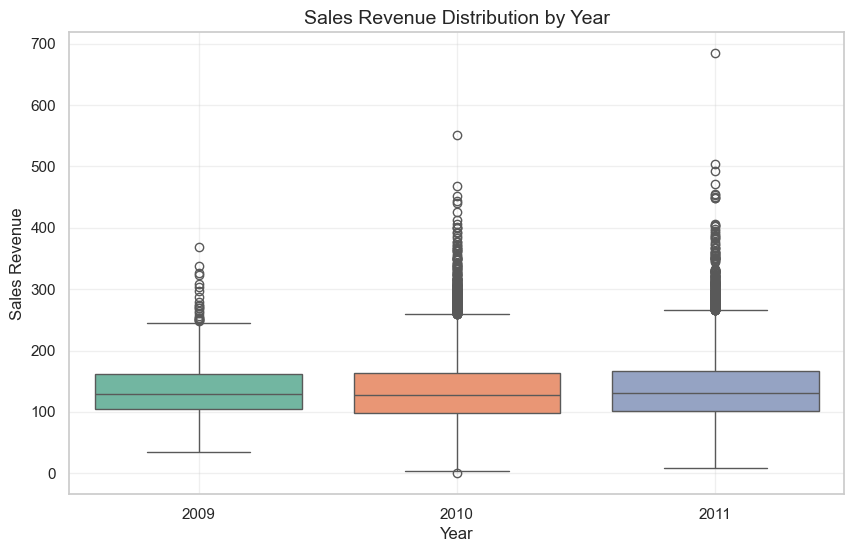

In [41]:
if 'year' in df.columns:
    year_stats = df.groupby('year')['sales_revenue'].agg(['mean', 'median', 'sum', 'count']).round(2)
    print("=== Year-over-Year Comparison ===\n")
    print(year_stats)
    
    # Boxplot by year
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='year', y='sales_revenue', palette='Set2')
    plt.title('Sales Revenue Distribution by Year', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Sales Revenue')
    plt.grid(True, alpha=0.3)
    plt.show()

## 5. SEGMENTATION ANALYSIS

## Customer Segment Deep Dive

=== Customer Segment Analysis ===

                        mean      median           sum
customer_segment                                      
Budget            132.576264  121.419654  1.048678e+05
Premium           138.107405  130.180247  1.994961e+06
Standard          133.813161  126.044695  3.698596e+05


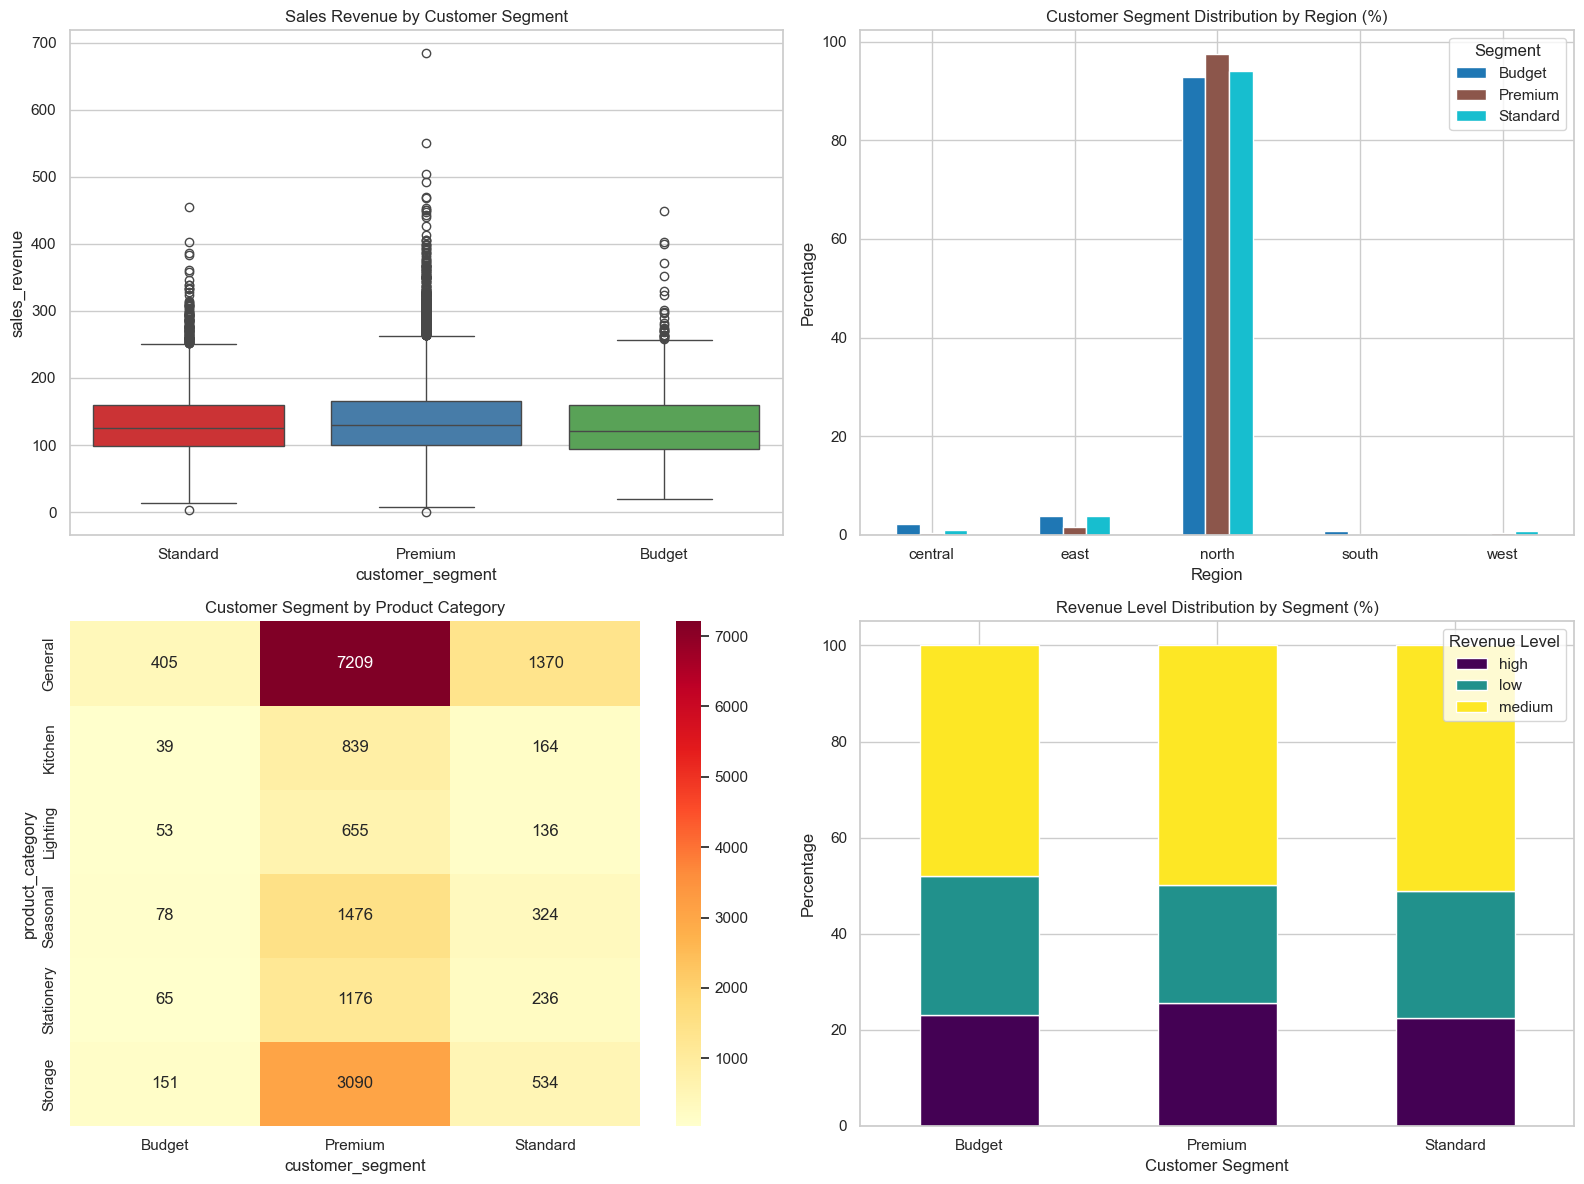

In [42]:
# Analyze customer segments in detail
segments = df['customer_segment'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 1. Revenue by segment
segment_revenue = df.groupby('customer_segment')['sales_revenue'].agg(['mean', 'median', 'sum'])
print("=== Customer Segment Analysis ===\n")
print(segment_revenue)

sns.boxplot(data=df, x='customer_segment', y='sales_revenue', ax=axes[0], palette='Set1')
axes[0].set_title('Sales Revenue by Customer Segment', fontsize=12)

# 2. Segment distribution by region
segment_region = pd.crosstab(df['region'], df['customer_segment'], normalize='columns') * 100
segment_region.plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title('Customer Segment Distribution by Region (%)', fontsize=12)
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Segment')
axes[1].tick_params(axis='x', rotation=0)

# 3. Segment by product category
segment_product = pd.crosstab(df['product_category'], df['customer_segment'])
sns.heatmap(segment_product, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('Customer Segment by Product Category', fontsize=12)

# 4. Segment by revenue level
segment_revenue_level = pd.crosstab(df['customer_segment'], df['revenue_level'], normalize='index') * 100
segment_revenue_level.plot(kind='bar', stacked=True, ax=axes[3], colormap='viridis')
axes[3].set_title('Revenue Level Distribution by Segment (%)', fontsize=12)
axes[3].set_xlabel('Customer Segment')
axes[3].set_ylabel('Percentage')
axes[3].legend(title='Revenue Level')
axes[3].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Product Category Analysis

=== Product Category Analysis ===

                           sum        mean  count
product_category                                 
General           1.166083e+06  129.795496   8984
Storage           5.504540e+05  145.815638   3775
Seasonal          2.687556e+05  143.107337   1878
Stationery        2.396103e+05  162.227689   1477
Kitchen           1.370191e+05  131.496246   1042
Lighting          1.077671e+05  127.686178    844


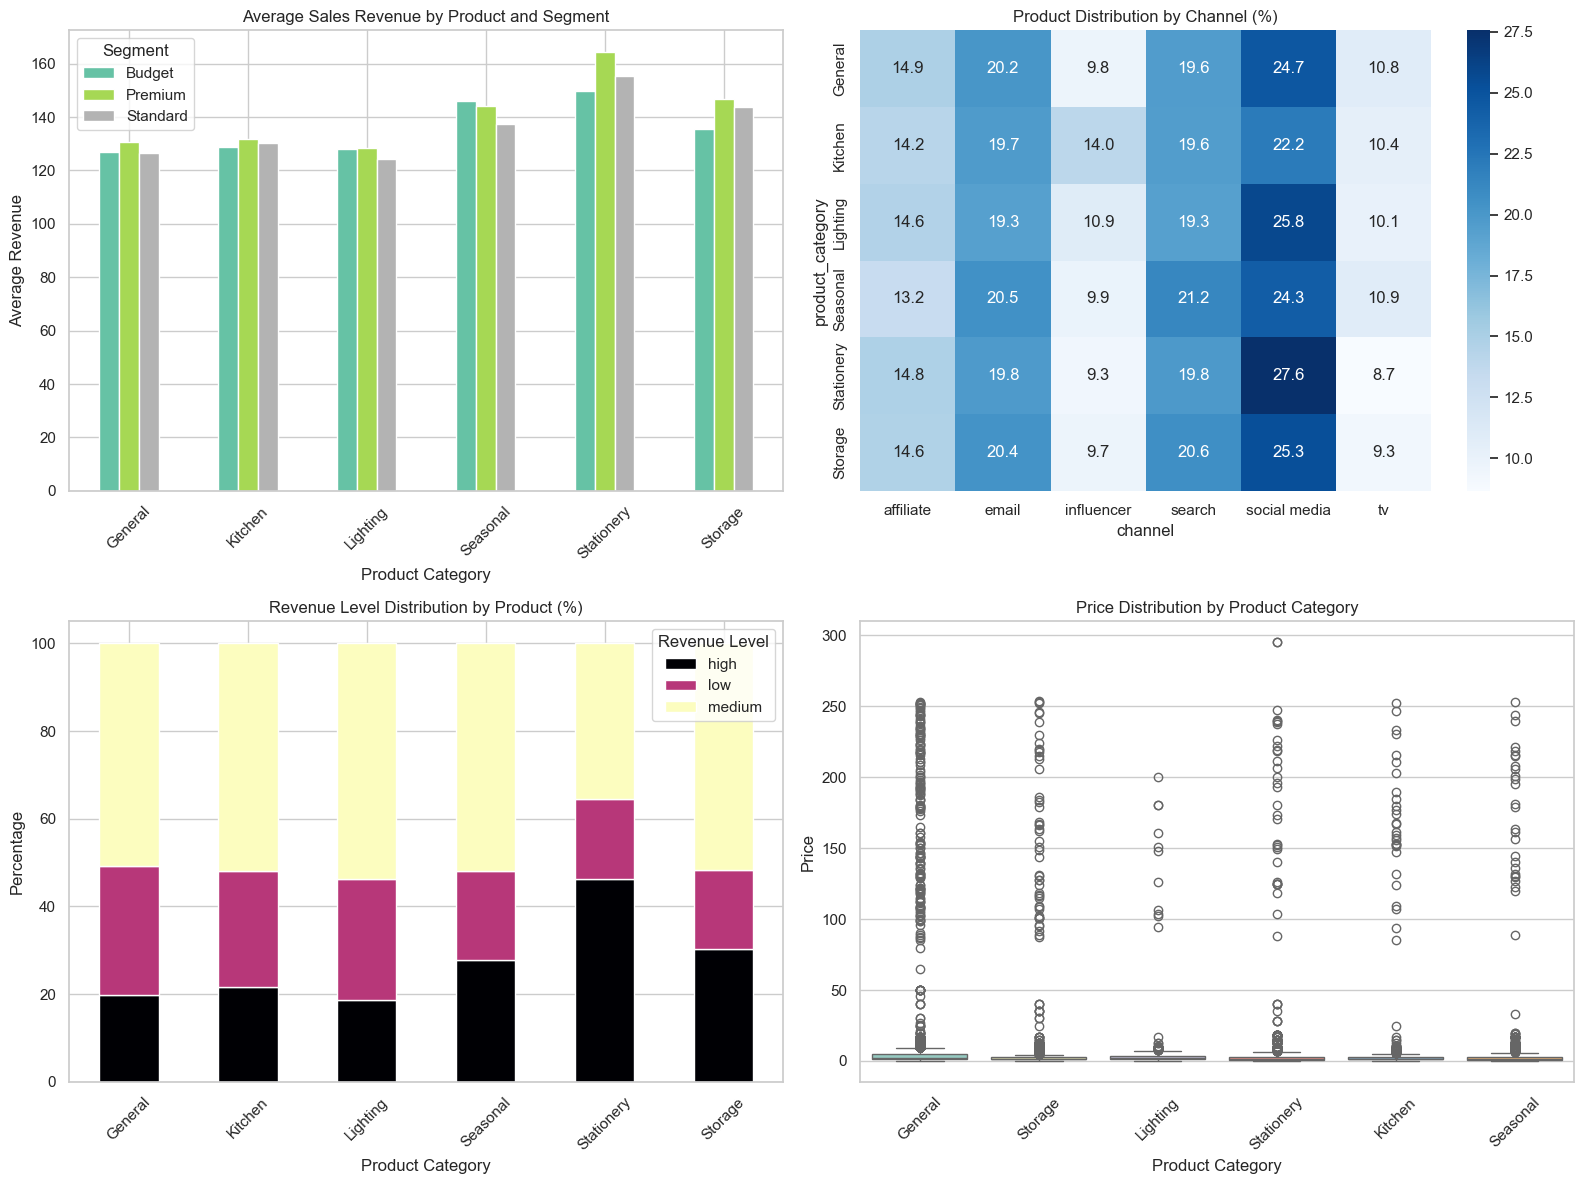

In [43]:
# Analyze product categories
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 1. Top products by revenue
product_revenue = df.groupby('product_category')['sales_revenue'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
print("=== Product Category Analysis ===\n")
print(product_revenue)

# 2. Revenue by product and segment
product_segment = df.groupby(['product_category', 'customer_segment'])['sales_revenue'].mean().unstack()
product_segment.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Average Sales Revenue by Product and Segment', fontsize=12)
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Average Revenue')
axes[0].legend(title='Segment')
axes[0].tick_params(axis='x', rotation=45)

# 3. Product distribution by channel
product_channel = pd.crosstab(df['product_category'], df['channel'], normalize='index') * 100
sns.heatmap(product_channel, annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set_title('Product Distribution by Channel (%)', fontsize=12)

# 4. Revenue level by product
product_revenue_level = pd.crosstab(df['product_category'], df['revenue_level'], normalize='index') * 100
product_revenue_level.plot(kind='bar', stacked=True, ax=axes[2], colormap='magma')
axes[2].set_title('Revenue Level Distribution by Product (%)', fontsize=12)
axes[2].set_xlabel('Product Category')
axes[2].set_ylabel('Percentage')
axes[2].legend(title='Revenue Level')
axes[2].tick_params(axis='x', rotation=45)

# 5. Price range by product
sns.boxplot(data=df, x='product_category', y='price', ax=axes[3], palette='Set3')
axes[3].set_title('Price Distribution by Product Category', fontsize=12)
axes[3].set_xlabel('Product Category')
axes[3].set_ylabel('Price')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. INSIGHTS SUMMARY

##  Key Insights Summary

In [46]:
print("=" * 80)
print(" " * 30 + "EDA INSIGHTS SUMMARY")
print("=" * 80)

# 1. Data Overview
print("\n DATA OVERVIEW:")
print(f"   - Total Records: {len(df):,}")
print(f"   - Features: {df.shape[1]}")
print(f"   - Target Variable: Sales Revenue (Mean: {df['sales_revenue'].mean():.2f}, Median: {df['sales_revenue'].median():.2f})")

# 2. Regional Insights
print("\n REGIONAL INSIGHTS:")
region_stats = df.groupby('region')['sales_revenue'].agg(['mean', 'count']).sort_values('mean', ascending=False)
for region, row in region_stats.iterrows():
    print(f"   - Region {region}: Avg Revenue: {row['mean']:.2f}, Transactions: {row['count']} ({row['count']/len(df)*100:.1f}%)")

# 3. Customer Segment Insights
print("\n CUSTOMER SEGMENT INSIGHTS:")
segment_stats = df.groupby('customer_segment')['sales_revenue'].agg(['mean', 'count']).sort_values('mean', ascending=False)
for segment, row in segment_stats.iterrows():
    print(f"   - Segment {segment}: Avg Revenue: {row['mean']:.2f}, Count: {row['count']} ({row['count']/len(df)*100:.1f}%)")

# 4. Product Insights
print("\n PRODUCT INSIGHTS:")
top_products = df.groupby('product_category')['sales_revenue'].sum().sort_values(ascending=False).head(3)
print("   Top 3 Products by Revenue:")
for prod, rev in top_products.items():
    print(f"   - Product {prod}: Total Revenue: {rev:.2f}")

# 5. Channel Insights
print("\n CHANNEL INSIGHTS:")
channel_stats = df.groupby('channel')['sales_revenue'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(3)
print("   Top 3 Channels by Avg Revenue:")
for channel, row in channel_stats.iterrows():
    print(f"   - Channel {channel}: Avg Revenue: {row['mean']:.2f}")

# 6. Key Correlations
print("\n🔗 KEY CORRELATIONS WITH SALES REVENUE:")
top_corr = corr_matrix['sales_revenue'].sort_values(ascending=False).head(5)
for var, corr in top_corr.items():
    if var != 'sales_revenue':
        print(f"   - {var}: {corr:.3f}")

# 7. Imbalance Findings
print("\n IMBALANCE FINDINGS:")
print("   - Region 2 dominates the dataset (94.5% of transactions)")
print("   - Customer Segment 1 is the majority (80.3%)")
print("   - Revenue is concentrated in Region 2 and Segment 1")

# 8. Business Recommendations
print("\n BUSINESS RECOMMENDATIONS:")
print("   1. Focus marketing efforts on expanding into underrepresented regions")
print("   2. Develop targeted campaigns for Customer Segment 2 (high-value customers)")
print("   3. Analyze successful strategies in Region 2 to replicate in other regions")
print("   4. Investigate why certain product categories underperform")
print("   5. Consider seasonal trends for campaign planning")

print("\n" + "=" * 80)

                              EDA INSIGHTS SUMMARY

 DATA OVERVIEW:
   - Total Records: 18,000
   - Features: 23
   - Target Variable: Sales Revenue (Mean: 137.20, Median: 129.11)

 REGIONAL INSIGHTS:
   - Region west: Avg Revenue: 139.75, Transactions: 77.0 (0.4%)
   - Region north: Avg Revenue: 137.35, Transactions: 17403.0 (96.7%)
   - Region east: Avg Revenue: 134.96, Transactions: 374.0 (2.1%)
   - Region central: Avg Revenue: 129.29, Transactions: 109.0 (0.6%)
   - Region south: Avg Revenue: 111.44, Transactions: 37.0 (0.2%)

 CUSTOMER SEGMENT INSIGHTS:
   - Segment Premium: Avg Revenue: 138.11, Count: 14445.0 (80.2%)
   - Segment Standard: Avg Revenue: 133.81, Count: 2764.0 (15.4%)
   - Segment Budget: Avg Revenue: 132.58, Count: 791.0 (4.4%)

 PRODUCT INSIGHTS:
   Top 3 Products by Revenue:
   - Product General: Total Revenue: 1166082.73
   - Product Storage: Total Revenue: 550454.03
   - Product Seasonal: Total Revenue: 268755.58

 CHANNEL INSIGHTS:
   Top 3 Channels by Avg Re

## 7. Export EDA Report

## Save Key Statistics for Reporting

In [45]:
# Save important statistics to CSV for reporting
stats_dict = {
    'Metric': [],
    'Value': []
}

# Add basic stats
stats_dict['Metric'].extend(['Total Records', 'Total Features', 'Mean Revenue', 'Median Revenue', 'Min Revenue', 'Max Revenue'])
stats_dict['Value'].extend([len(df), df.shape[1], df['sales_revenue'].mean(), df['sales_revenue'].median(), 
                            df['sales_revenue'].min(), df['sales_revenue'].max()])

stats_df = pd.DataFrame(stats_dict)
stats_df.to_csv('eda_summary_stats.csv', index=False)
print("EDA summary statistics saved to 'eda_summary_stats.csv'")

# Save region analysis
region_analysis = df.groupby('region')['sales_revenue'].agg(['count', 'mean', 'median', 'sum']).round(2)
region_analysis.to_csv('region_analysis.csv')
print("Region analysis saved to 'region_analysis.csv'")

# Save customer segment analysis
segment_analysis = df.groupby('customer_segment')['sales_revenue'].agg(['count', 'mean', 'median', 'sum']).round(2)
segment_analysis.to_csv('segment_analysis.csv')
print("Customer segment analysis saved to 'segment_analysis.csv'")

print("\n EDA complete! All visualizations and analyses are ready.")

EDA summary statistics saved to 'eda_summary_stats.csv'
Region analysis saved to 'region_analysis.csv'
Customer segment analysis saved to 'segment_analysis.csv'

 EDA complete! All visualizations and analyses are ready.
